# Élaborez un modèle de scoring

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.preprocessing import LabelEncoder, StandardScaler
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.lightgbm
from sklearn.metrics import roc_auc_score, recall_score, f1_score, confusion_matrix, make_scorer
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.neural_network import MLPClassifier

from sklearn.metrics import roc_auc_score

import time

from mlflow import MlflowClient

import shap

/home/maximilien/Documents/Projet_6/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Objectif

Développer un modèle de scoring capable de prédire le risque de défaut de paiement afin d'aider un organisme de crédit à prendre ses décisions.

## Exploration des données

L'analyse exploratoire présentée dans ce notebook s'inspire du notebook Kaggle Start Here: A Gentle Introduction de Will Koehrsen, réalisé dans le cadre de la compétition Home Credit Default Risk.

In [2]:
colonnes = pd.read_csv("HomeCredit_columns_description.csv",  encoding="latin1")
colonnes.head()

,Unnamed: 0,Table,Row,Description,Special
0,1,application_{train|test}.csv,SK_ID_CURR,ID of loan in our sample,NaN
1,2,application_{train|test}.csv,TARGET,Target variable (1 - client with payment diffi...,NaN
2,5,application_{train|test}.csv,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
3,6,application_{train|test}.csv,CODE_GENDER,Gender of the client,NaN
4,7,application_{train|test}.csv,FLAG_OWN_CAR,Flag if the client owns a car,NaN


In [3]:
colonnes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 219 entries, 0 to 218
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   219 non-null    int64 
 1   Table        219 non-null    object
 2   Row          219 non-null    object
 3   Description  219 non-null    object
 4   Special      86 non-null     object
dtypes: int64(1), object(4)
memory usage: 8.7+ KB


219 lignes pour 5 colonnes.
Ce tableau renseigne chaque colonnes des différents dataset.

In [4]:
colonnes[colonnes.duplicated()]

,Unnamed: 0,Table,Row,Description,Special


pas de doublons dans ce dataset.

In [5]:
colonnes["Row"].nunique()

196

On a donc au plus 196 varaibles différentes toutes tables confondues.

In [6]:
colonnes.count()

Unnamed: 0     219
Table          219
Row            219
Description    219
Special         86
dtype: int64

In [7]:
application_train = pd.read_csv("application_train.csv")
application_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
application_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


307 511 lignes et 122 colonnes.

In [9]:
application_train.nunique().sort_values(ascending = False)

SK_ID_CURR           307511
EXT_SOURCE_2         119831
EXT_SOURCE_1         114584
DAYS_BIRTH            17460
DAYS_REGISTRATION     15688
                      ...  
FLAG_DOCUMENT_16          2
FLAG_DOCUMENT_15          2
FLAG_DOCUMENT_14          2
FLAG_DOCUMENT_20          2
FLAG_DOCUMENT_21          2
Length: 122, dtype: int64

La clée primaire de la table application_train est SK_ID_CURR.  
Chaque ligne correspond à un client.  
La cible est la variable TARGET, qui informe si le cient a remboursé son crédit ou non.

In [10]:
application_train["TARGET"].value_counts(normalize = True).reset_index()*100

,TARGET,proportion
0,0,91.927118
1,100,8.072882


On observe un déséquilibre de la cible. La part de client ayant rembourssé leur crédit est beaucoup plus importante que celle de client ayant fait un défaut de paiement.

In [11]:
application_train[application_train.duplicated()]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR


Il n'y a pas de doublons dans cette table.

In [12]:
application_train.isna().mean().sort_values(ascending = False)

COMMONAREA_AVG              0.698723
COMMONAREA_MODE             0.698723
COMMONAREA_MEDI             0.698723
NONLIVINGAPARTMENTS_MEDI    0.694330
NONLIVINGAPARTMENTS_MODE    0.694330
                              ...   
FLAG_DOCUMENT_16            0.000000
FLAG_DOCUMENT_15            0.000000
FLAG_DOCUMENT_14            0.000000
FLAG_DOCUMENT_20            0.000000
FLAG_DOCUMENT_21            0.000000
Length: 122, dtype: float64

<Axes: >

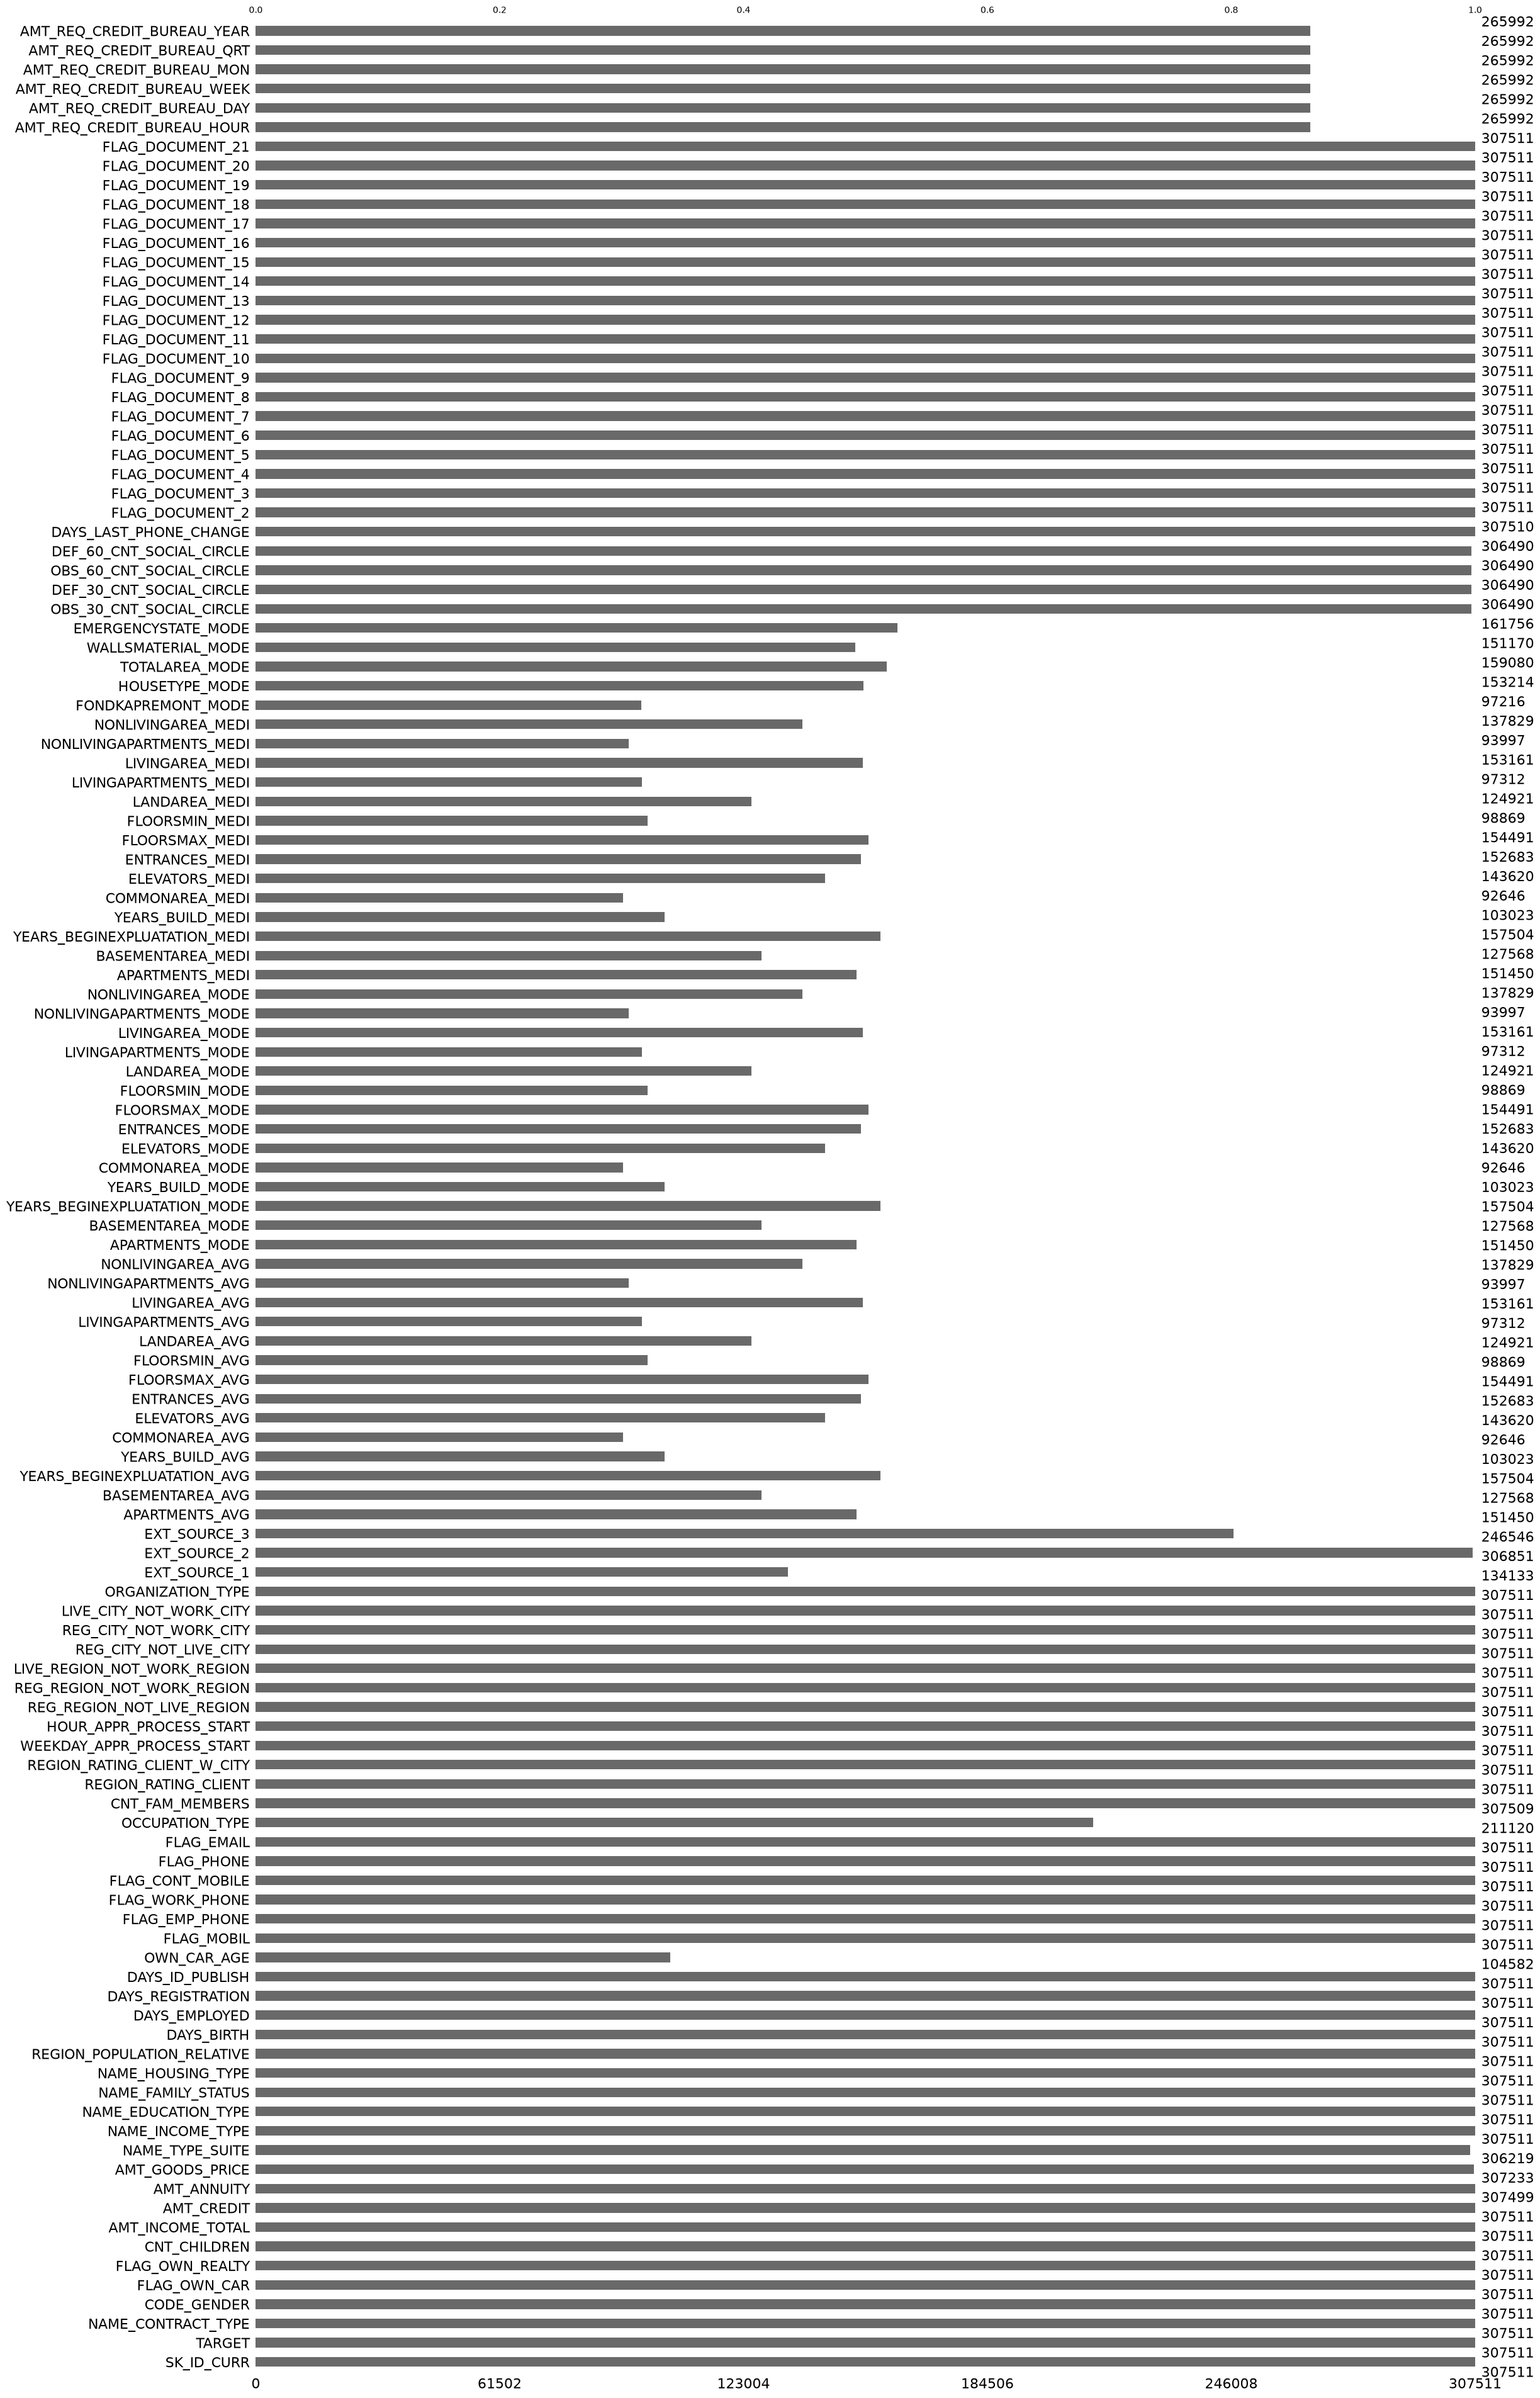

In [13]:
msno.bar(application_train)

Il s'agit de la table principale, sur laquelle on entrainnera les modèles et verifiera leur performances.

In [14]:
application_test = pd.read_csv("application_test.csv")
application_test.head()

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
application_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Columns: 121 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(40), object(16)
memory usage: 45.0+ MB


48 744 lignes et 121 colonnes.  
Ce tableau a la même structure que application_train, sans la colonne cible (TARGET)

In [16]:
application_test[application_test.duplicated()]

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR


Il n'y a pas de doublons.

In [17]:
application_test["SK_ID_CURR"].is_unique

True

SK_ID_CURR est la clée unique de application_test, et chaque ligne correspond à un client.

In [18]:
application_test.isna().mean().sort_values(ascending = False)

COMMONAREA_AVG              0.687161
COMMONAREA_MEDI             0.687161
COMMONAREA_MODE             0.687161
NONLIVINGAPARTMENTS_AVG     0.684125
NONLIVINGAPARTMENTS_MEDI    0.684125
                              ...   
FLAG_DOCUMENT_16            0.000000
FLAG_DOCUMENT_15            0.000000
FLAG_DOCUMENT_14            0.000000
FLAG_DOCUMENT_20            0.000000
FLAG_DOCUMENT_21            0.000000
Length: 121, dtype: float64

<Axes: >

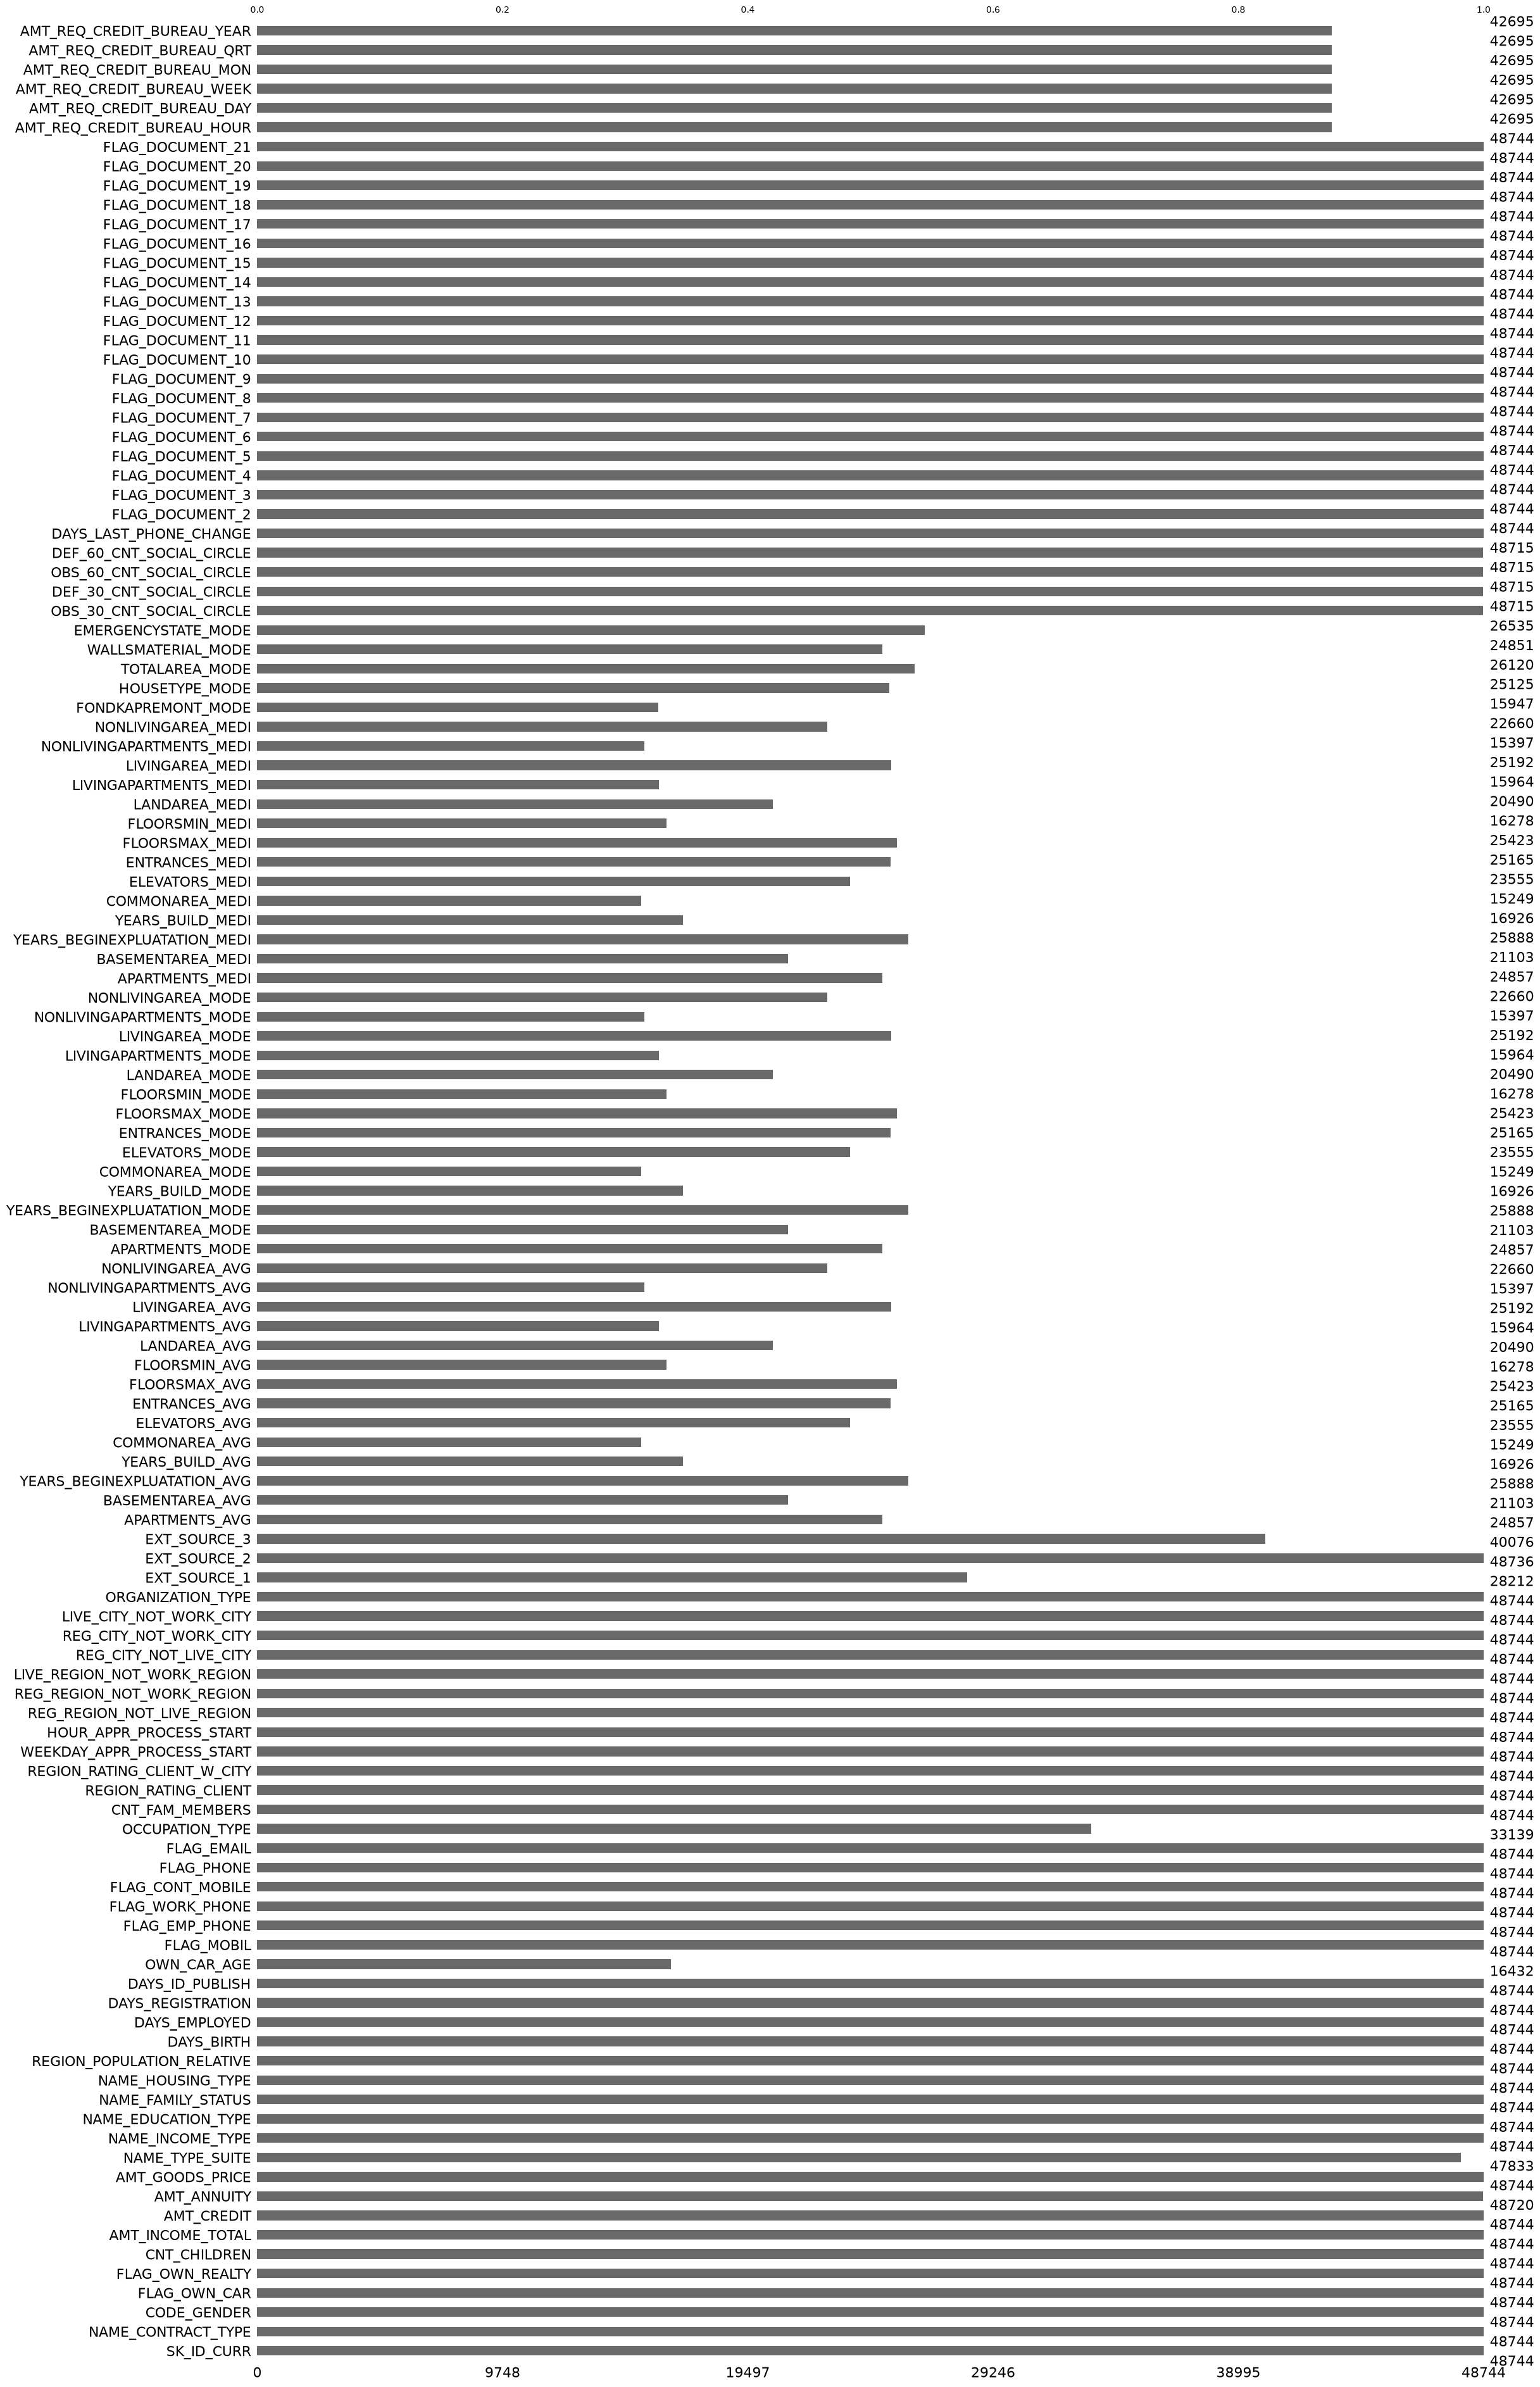

In [19]:
msno.bar(application_test)

On concerve toutes les variables de application_train et application_test.

Regardons le nombre de colonnes de chaque types:

In [20]:
application_train.dtypes.value_counts()

float64    65
int64      41
object     16
Name: count, dtype: int64

Regardons la proportion de valeurs manquantes parmi les variables categorielles:

In [21]:
application_train.select_dtypes(include="object").isna().sum().sort_values(ascending = False)

FONDKAPREMONT_MODE            210295
WALLSMATERIAL_MODE            156341
HOUSETYPE_MODE                154297
EMERGENCYSTATE_MODE           145755
OCCUPATION_TYPE                96391
NAME_TYPE_SUITE                 1292
FLAG_OWN_CAR                       0
NAME_CONTRACT_TYPE                 0
NAME_FAMILY_STATUS                 0
NAME_EDUCATION_TYPE                0
NAME_INCOME_TYPE                   0
FLAG_OWN_REALTY                    0
CODE_GENDER                        0
ORGANIZATION_TYPE                  0
NAME_HOUSING_TYPE                  0
WEEKDAY_APPR_PROCESS_START         0
dtype: int64

créons une catégorie "Missing" pour ces variables:

In [22]:
for col in application_train:
    if application_train[col].dtype == 'object':
        application_train[col] = application_train[col].fillna("Missing")

application_train.select_dtypes(include="object").isna().sum().sort_values(ascending = False)

NAME_CONTRACT_TYPE            0
CODE_GENDER                   0
FLAG_OWN_CAR                  0
FLAG_OWN_REALTY               0
NAME_TYPE_SUITE               0
NAME_INCOME_TYPE              0
NAME_EDUCATION_TYPE           0
NAME_FAMILY_STATUS            0
NAME_HOUSING_TYPE             0
OCCUPATION_TYPE               0
WEEKDAY_APPR_PROCESS_START    0
ORGANIZATION_TYPE             0
FONDKAPREMONT_MODE            0
HOUSETYPE_MODE                0
WALLSMATERIAL_MODE            0
EMERGENCYSTATE_MODE           0
dtype: int64

On effectue le même traitement sut application_test:

In [23]:
application_test.select_dtypes(include="object").isna().sum().sort_values(ascending = False)

FONDKAPREMONT_MODE            32797
WALLSMATERIAL_MODE            23893
HOUSETYPE_MODE                23619
EMERGENCYSTATE_MODE           22209
OCCUPATION_TYPE               15605
NAME_TYPE_SUITE                 911
FLAG_OWN_CAR                      0
NAME_CONTRACT_TYPE                0
NAME_FAMILY_STATUS                0
NAME_EDUCATION_TYPE               0
NAME_INCOME_TYPE                  0
FLAG_OWN_REALTY                   0
CODE_GENDER                       0
ORGANIZATION_TYPE                 0
NAME_HOUSING_TYPE                 0
WEEKDAY_APPR_PROCESS_START        0
dtype: int64

In [24]:
for col in application_test:
    if application_test[col].dtype == 'object':
        application_test[col] = application_test[col].fillna("Missing")

application_test.select_dtypes(include="object").isna().sum().sort_values(ascending = False)

NAME_CONTRACT_TYPE            0
CODE_GENDER                   0
FLAG_OWN_CAR                  0
FLAG_OWN_REALTY               0
NAME_TYPE_SUITE               0
NAME_INCOME_TYPE              0
NAME_EDUCATION_TYPE           0
NAME_FAMILY_STATUS            0
NAME_HOUSING_TYPE             0
OCCUPATION_TYPE               0
WEEKDAY_APPR_PROCESS_START    0
ORGANIZATION_TYPE             0
FONDKAPREMONT_MODE            0
HOUSETYPE_MODE                0
WALLSMATERIAL_MODE            0
EMERGENCYSTATE_MODE           0
dtype: int64

Observons nos variables quantitatives:

In [25]:
pd.set_option('display.max_columns', None)
application_train.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,104582.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307509.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,134133.000000,3.068510e+05,246546.000000,151450.00000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,151450.000000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,151450.000000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,159080.000000,306490.000000,306490.000000,306490.000000,306490.000000,307510.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.00000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,-4986.120328,-2994.202373,12.061091,0.999997,0.819889,0.199368,0.998133,0.281066,0.056720,2.152665,2.052463,2.031521,12.063419,0.015144,0.050769,0.040659,0.078173,0.230454,0.179555,0.502130,5.143927e-01,0.510853,0.11744,0.088442,0.977735,0.752471,0.044621,0.078942,0.149725,0.226282,0.231894,0.066333,0.100775,0.107399,0.008809,0.028358,0.114231,0.087543,0.977065,0.759637,0.042553,0.074490,0.145193,0.222315,0.228058,0.064958,0.105645,0.105975,0.008076,0.027022,0.117850,0.087955,0.97

On notte une valeur extrème pour la variable DAYS_EMPLOYED (ancienneté professionnelle), 365 243.

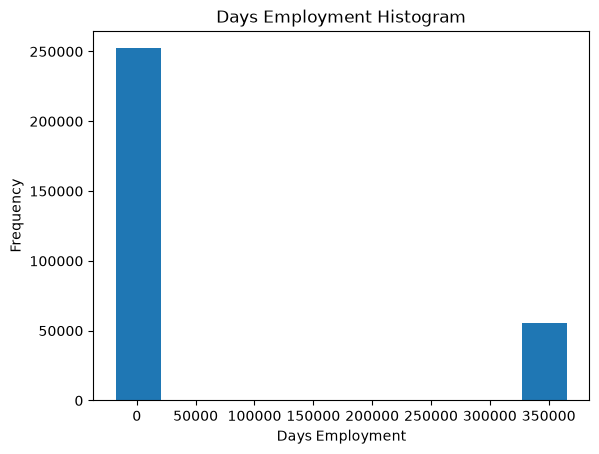

In [26]:
application_train['DAYS_EMPLOYED'].plot.hist(title = 'Days Employment Histogram');
plt.xlabel('Days Employment');

Observons si les clients présentants cette anomalie, ont un taux de défaut de paiement plus ou moins élevé que le reste des clients.

In [27]:
anom = application_train[application_train['DAYS_EMPLOYED'] == 365243]
non_anom = application_train[application_train['DAYS_EMPLOYED'] != 365243]
print('les cients ne présentants pas cette anomalie ont un défaut de paiement sur %0.2f%% des prets' % (100 * non_anom['TARGET'].mean()))
print('les clients présentants cette anoùmalie ont un défaut de paiement sur %0.2f%% des prets' % (100 * anom['TARGET'].mean()))
print('on observe %d valeurs anormales dans la variable days of employment' % len(anom))

les cients ne présentants pas cette anomalie ont un défaut de paiement sur 8.66% des prets
les clients présentants cette anoùmalie ont un défaut de paiement sur 5.40% des prets
on observe 55374 valeurs anormales dans la variable days of employment


Il s'avère que les observations présentant cette anomalie ont un taux de défaut de paiement plus faible que les autres.

Dans ce cas précis, toutes les anomalies prennent exactement la même valeur. Il est donc préférable de les remplacer toutes de la même manière, car il est possible que ces prêts aient une caractéristique commune.

Ces valeurs anormales semblent contenir une information pertinente. Il est donc utile d'indiquer explicitement au modèle de machine learning quelles observations contenaient une anomalie.

La solution retenue est donc la suivante :

- remplacer les valeurs anormales par np.nan (valeur manquante) ;
- créer une nouvelle variable booléenne indiquant si la valeur d'origine était ou non une anomalie.

Ainsi, le modèle pourra à la fois bénéficier de l'imputation des valeurs manquantes et conserver l'information selon laquelle certaines observations étaient initialement anormales.

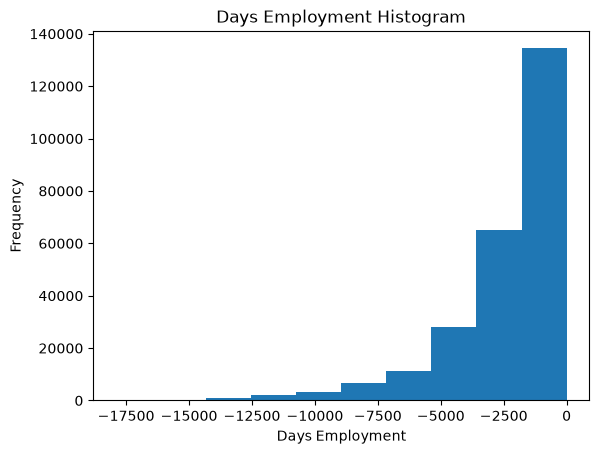

In [28]:
# Creation d'une nouvelle variable booléenne identifiant les clients dont Days_employed est une anomalie
application_train['DAYS_EMPLOYED_ANOM'] = (application_train["DAYS_EMPLOYED"] == 365243).astype("int")

# On remplace cette valeur par NaN dans la colonne DAYS_EMPLOYED.
application_train['DAYS_EMPLOYED'] = application_train['DAYS_EMPLOYED'].replace({365243: np.nan})

application_train['DAYS_EMPLOYED'].plot.hist(title = 'Days Employment Histogram');
plt.xlabel('Days Employment');


La distribution semble plus cohérente. De plus, nous avons créé une nouvelle colonne permettant d'indiquer au modèle que ces valeurs étaient initialement des anomalies (car nous devrons remplacer les NaN par une valeur, probablement la médiane de la colonne).

Les autres variables du jeu de données dont le nom contient DAYS présentent des distributions qui semblent normales, sans valeurs aberrantes évidentes.

Point très important : toutes les transformations appliquées aux données d'entraînement (training data) doivent également être appliquées aux données de test (testing data).

Nous devons donc nous assurer de :

- créer la même colonne booléenne dans le jeu de données de test ;
- remplacer, dans ce jeu également, les valeurs anormales de DAYS_EMPLOYED par np.nan.

Cette cohérence est essentielle, car le modèle doit recevoir des données ayant exactement la même structure et les mêmes prétraitements lors de l'entraînement et de la phase de prédiction.

In [29]:
application_test['DAYS_EMPLOYED_ANOM'] = (application_test["DAYS_EMPLOYED"] == 365243).astype("int")
application_test["DAYS_EMPLOYED"] = application_test["DAYS_EMPLOYED"].replace({365243: np.nan})

print('Il y a %d anomalies dans le jeu de données de test sur %d entrées' % (application_test["DAYS_EMPLOYED_ANOM"].sum(), len(application_test)))


Il y a 9274 anomalies dans le jeu de données de test sur 48744 entrées


Regardons le nombre de catégories pour chaque variables catégorielles:

In [30]:
application_train.select_dtypes(include=['object']).apply(pd.Series.nunique)

NAME_CONTRACT_TYPE             2
CODE_GENDER                    3
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
NAME_TYPE_SUITE                8
NAME_INCOME_TYPE               8
NAME_EDUCATION_TYPE            5
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
OCCUPATION_TYPE               19
WEEKDAY_APPR_PROCESS_START     7
ORGANIZATION_TYPE             58
FONDKAPREMONT_MODE             5
HOUSETYPE_MODE                 4
WALLSMATERIAL_MODE             8
EMERGENCYSTATE_MODE            3
dtype: int64

On effectue un labelencoding sur les variables categorielles qui ont au maximums deux valeurs possibles:

In [31]:
le_count = 0

for col in application_train:
    if application_train[col].dtype == 'object':
        if len(list(application_train[col].unique())) <= 2:
            le = LabelEncoder().fit(application_train[col])
            application_train[col] = le.transform(application_train[col])
            application_test[col] = le.transform(application_test[col]) # On effectue les mêmes traitement sur le test
            
            le_count += 1
            
print('%d colonnes encodées' % le_count)

3 colonnes encodées


On effectue un onehot encoding sur les variables categorielles restantes:

In [32]:
application_train = pd.get_dummies(application_train)
application_test = pd.get_dummies(application_test) # On effectue les mêmes traitements sur le test

print('Nombre de colonnes train: ', application_train.shape[1])
print('Nombre de clonnes test: ', application_test.shape[1])

Nombre de colonnes train:  250
Nombre de clonnes test:  246


On a pas le même nombre de colonnes dans le train et dans le test, donc il faut alligner les deux datasets:

In [33]:
# on garde la target dans une variable pour eviter de la perdre après l'allignement des deux datasets (inner)
train_labels = application_train['TARGET']

# On alligne les deux dataset sur les colonnes presentes dans les deux dataset(inner)
application_train, application_test = application_train.align(application_test, join = 'inner', axis = 1)

# on ajoute la target a application_train
application_train['TARGET'] = train_labels

print('nombre de colonnes train: ', application_train.shape[1])
print('nombre de colonnes test: ', application_test.shape[1])

nombre de colonnes train:  247
nombre de colonnes test:  246


Regardons les corrélations les plus fortes avec la variable cible.

In [34]:
# On reécupère les corrélations avec la variable cible et les trier
correlations = application_train.corr()['TARGET'].sort_values()

# Afficher les corrélations
print('Corrélations les plus positives :\n', correlations.tail(15))
print('\nCorrélations les plus négatives :\n', correlations.head(15))

Corrélations les plus positives :
 OCCUPATION_TYPE_Laborers                             0.043019
FLAG_DOCUMENT_3                                      0.044346
REG_CITY_NOT_LIVE_CITY                               0.044395
FLAG_EMP_PHONE                                       0.045982
NAME_EDUCATION_TYPE_Secondary / secondary special    0.049824
REG_CITY_NOT_WORK_CITY                               0.050994
DAYS_ID_PUBLISH                                      0.051457
CODE_GENDER_M                                        0.054713
DAYS_LAST_PHONE_CHANGE                               0.055218
NAME_INCOME_TYPE_Working                             0.057481
REGION_RATING_CLIENT                                 0.058899
REGION_RATING_CLIENT_W_CITY                          0.060893
DAYS_EMPLOYED                                        0.074958
DAYS_BIRTH                                           0.078239
TARGET                                               1.000000
Name: TARGET, dtype: float64

Corré

On remarque que les variables sont globalement faiblement corrélées avec la cible.

In [35]:
application_train.isna().mean().sort_values(ascending = False).head(20)

COMMONAREA_AVG              0.698723
COMMONAREA_MODE             0.698723
COMMONAREA_MEDI             0.698723
NONLIVINGAPARTMENTS_MODE    0.694330
NONLIVINGAPARTMENTS_MEDI    0.694330
NONLIVINGAPARTMENTS_AVG     0.694330
LIVINGAPARTMENTS_AVG        0.683550
LIVINGAPARTMENTS_MODE       0.683550
LIVINGAPARTMENTS_MEDI       0.683550
FLOORSMIN_MODE              0.678486
FLOORSMIN_MEDI              0.678486
FLOORSMIN_AVG               0.678486
YEARS_BUILD_MEDI            0.664978
YEARS_BUILD_AVG             0.664978
YEARS_BUILD_MODE            0.664978
OWN_CAR_AGE                 0.659908
LANDAREA_AVG                0.593767
LANDAREA_MEDI               0.593767
LANDAREA_MODE               0.593767
BASEMENTAREA_MODE           0.585160
dtype: float64

On divisera application_test en X_train et X_validation.  
On comblera les NaN avec la médiane pour chaque colonnes pour limiter l'effet des grandes valeurs.

In [36]:
# Variable cible
target = "TARGET"

# Suppression de l'identifiant client
X = application_train.drop(columns=[target])

y = application_train[target]

# Séparation en train et validation_test
X_train, X_validation_test, y_train, y_validation_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

# Séparation validation et test
X_validation, X_test, y_validation, y_test = train_test_split(X_validation_test, y_validation_test, test_size=0.50, stratify=y_validation_test, random_state=42)

In [37]:
# Remplace toutes les valeurs manquantes par la médiane de chaque colonne numérique
X_train = X_train.fillna(X_train.median(numeric_only=True))
X_validation = X_validation.fillna(X_train.median(numeric_only=True))
X_test = X_test.fillna(X_train.median(numeric_only=True))

In [38]:
X_train.isna().mean().sort_values(ascending = False).head(20)

SK_ID_CURR                    0.0
NAME_CONTRACT_TYPE            0.0
FLAG_OWN_CAR                  0.0
FLAG_OWN_REALTY               0.0
CNT_CHILDREN                  0.0
AMT_INCOME_TOTAL              0.0
AMT_CREDIT                    0.0
AMT_ANNUITY                   0.0
AMT_GOODS_PRICE               0.0
REGION_POPULATION_RELATIVE    0.0
DAYS_BIRTH                    0.0
DAYS_EMPLOYED                 0.0
DAYS_REGISTRATION             0.0
DAYS_ID_PUBLISH               0.0
OWN_CAR_AGE                   0.0
FLAG_MOBIL                    0.0
FLAG_EMP_PHONE                0.0
FLAG_WORK_PHONE               0.0
FLAG_CONT_MOBILE              0.0
FLAG_PHONE                    0.0
dtype: float64

In [39]:
bureau = pd.read_csv("bureau.csv")
bureau.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [40]:
bureau.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_CURR              int64  
 1   SK_ID_BUREAU            int64  
 2   CREDIT_ACTIVE           object 
 3   CREDIT_CURRENCY         object 
 4   DAYS_CREDIT             int64  
 5   CREDIT_DAY_OVERDUE      int64  
 6   DAYS_CREDIT_ENDDATE     float64
 7   DAYS_ENDDATE_FACT       float64
 8   AMT_CREDIT_MAX_OVERDUE  float64
 9   CNT_CREDIT_PROLONG      int64  
 10  AMT_CREDIT_SUM          float64
 11  AMT_CREDIT_SUM_DEBT     float64
 12  AMT_CREDIT_SUM_LIMIT    float64
 13  AMT_CREDIT_SUM_OVERDUE  float64
 14  CREDIT_TYPE             object 
 15  DAYS_CREDIT_UPDATE      int64  
 16  AMT_ANNUITY             float64
dtypes: float64(8), int64(6), object(3)
memory usage: 222.6+ MB


Tableau de 1 716 428 lignes et 17 colonnes.

In [41]:
bureau[bureau.duplicated()]

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY


Pas de doublons dans ce dataset.

In [42]:
bureau.isna().mean().sort_values(ascending = False)

AMT_ANNUITY               0.714735
AMT_CREDIT_MAX_OVERDUE    0.655133
DAYS_ENDDATE_FACT         0.369170
AMT_CREDIT_SUM_LIMIT      0.344774
AMT_CREDIT_SUM_DEBT       0.150119
DAYS_CREDIT_ENDDATE       0.061496
AMT_CREDIT_SUM            0.000008
SK_ID_CURR                0.000000
SK_ID_BUREAU              0.000000
CREDIT_DAY_OVERDUE        0.000000
CREDIT_ACTIVE             0.000000
CREDIT_CURRENCY           0.000000
DAYS_CREDIT               0.000000
CNT_CREDIT_PROLONG        0.000000
AMT_CREDIT_SUM_OVERDUE    0.000000
CREDIT_TYPE               0.000000
DAYS_CREDIT_UPDATE        0.000000
dtype: float64

In [43]:
bureau.nunique()

SK_ID_CURR                 305811
SK_ID_BUREAU              1716428
CREDIT_ACTIVE                   4
CREDIT_CURRENCY                 4
DAYS_CREDIT                  2923
CREDIT_DAY_OVERDUE            942
DAYS_CREDIT_ENDDATE         14096
DAYS_ENDDATE_FACT            2917
AMT_CREDIT_MAX_OVERDUE      68251
CNT_CREDIT_PROLONG             10
AMT_CREDIT_SUM             236708
AMT_CREDIT_SUM_DEBT        226537
AMT_CREDIT_SUM_LIMIT        51726
AMT_CREDIT_SUM_OVERDUE       1616
CREDIT_TYPE                    15
DAYS_CREDIT_UPDATE           2982
AMT_ANNUITY                 40321
dtype: int64

In [44]:
bureau["SK_ID_BUREAU"].is_unique

True

SK_ID_CURR est une clée étrangère de bureau.  
SK_ID_BUREAU est la clée primaire de bureau.  
Chaque ligne correspond à un crédit externe pour un client.  
La table bureau du dataset Home Credit contient donc l'historique des crédits que le client a eus auprès d'autres organismes financiers (et non chez Home Credit).

In [45]:
bureau_balance = pd.read_csv("bureau_balance.csv")
bureau_balance.head()

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C


In [46]:
bureau_balance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27299925 entries, 0 to 27299924
Data columns (total 3 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   SK_ID_BUREAU    int64 
 1   MONTHS_BALANCE  int64 
 2   STATUS          object
dtypes: int64(2), object(1)
memory usage: 624.8+ MB


27 299 925 lignes et 3 colonnes.  
bureau_balance est la table qui contient l'historique mensuel des crédits présents dans bureau.

In [47]:
bureau_balance.nunique()

SK_ID_BUREAU      817395
MONTHS_BALANCE        97
STATUS                 8
dtype: int64

In [48]:
bureau_balance[bureau_balance.duplicated()]

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS


Pas de doublons.

In [49]:
previous_application = pd.read_csv("previous_application.csv")
previous_application.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,FLAG_LAST_APPL_PER_CONTRACT,NFLAG_LAST_APPL_IN_DAY,RATE_DOWN_PAYMENT,RATE_INTEREST_PRIMARY,RATE_INTEREST_PRIVILEGED,NAME_CASH_LOAN_PURPOSE,NAME_CONTRACT_STATUS,DAYS_DECISION,NAME_PAYMENT_TYPE,CODE_REJECT_REASON,NAME_TYPE_SUITE,NAME_CLIENT_TYPE,NAME_GOODS_CATEGORY,NAME_PORTFOLIO,NAME_PRODUCT_TYPE,CHANNEL_TYPE,SELLERPLACE_AREA,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,Y,1,0.0,0.182832,0.867336,XAP,Approved,-73,Cash through the bank,XAP,NaN,Repeater,Mobile,POS,XNA,Country-wide,35,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-164,XNA,XAP,Unaccompanied,Repeater,XNA,Cash,x-sell,Contact center,-1,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-301,Cash through the bank,XAP,"Spouse, partner",Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,Y,1,NaN,NaN,NaN,XNA,Approved,-512,Cash through the bank,XAP,NaN,Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,Y,1,NaN,NaN,NaN,Repairs,Refused,-781,Cash through the bank,HC,NaN,Repeater,XNA,Cash,walk-in,Credit and cash offices,-1,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [50]:
previous_application.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 37 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1670214 non-null  int64  
 1   SK_ID_CURR                   1670214 non-null  int64  
 2   NAME_CONTRACT_TYPE           1670214 non-null  object 
 3   AMT_ANNUITY                  1297979 non-null  float64
 4   AMT_APPLICATION              1670214 non-null  float64
 5   AMT_CREDIT                   1670213 non-null  float64
 6   AMT_DOWN_PAYMENT             774370 non-null   float64
 7   AMT_GOODS_PRICE              1284699 non-null  float64
 8   WEEKDAY_APPR_PROCESS_START   1670214 non-null  object 
 9   HOUR_APPR_PROCESS_START      1670214 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1670214 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1670214 non-null  int64  
 12  RATE_DOWN_PAYMENT            774370 non-nu

1 670 214 lignes pour 37 colonnes

In [51]:
previous_application.nunique()

SK_ID_PREV                     1670214
SK_ID_CURR                      338857
NAME_CONTRACT_TYPE                   4
AMT_ANNUITY                     357959
AMT_APPLICATION                  93885
AMT_CREDIT                       86803
AMT_DOWN_PAYMENT                 29278
AMT_GOODS_PRICE                  93885
WEEKDAY_APPR_PROCESS_START           7
HOUR_APPR_PROCESS_START             24
FLAG_LAST_APPL_PER_CONTRACT          2
NFLAG_LAST_APPL_IN_DAY               2
RATE_DOWN_PAYMENT               207033
RATE_INTEREST_PRIMARY              148
RATE_INTEREST_PRIVILEGED            25
NAME_CASH_LOAN_PURPOSE              25
NAME_CONTRACT_STATUS                 4
DAYS_DECISION                     2922
NAME_PAYMENT_TYPE                    4
CODE_REJECT_REASON                   9
NAME_TYPE_SUITE                      7
NAME_CLIENT_TYPE                     4
NAME_GOODS_CATEGORY                 28
NAME_PORTFOLIO                       5
NAME_PRODUCT_TYPE                    3
CHANNEL_TYPE             

la clée primaire est SK_ID_PREV (identifiant unique d’une demande de prêt précédente)  
Et SK_ID_CURR est une clée étrangère.  
La table previous_application contient l'historique de toutes les demandes de crédit précédentes effectuées par le client auprès de Home Credit.

In [52]:
previous_application[previous_application.duplicated()]

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,FLAG_LAST_APPL_PER_CONTRACT,NFLAG_LAST_APPL_IN_DAY,RATE_DOWN_PAYMENT,RATE_INTEREST_PRIMARY,RATE_INTEREST_PRIVILEGED,NAME_CASH_LOAN_PURPOSE,NAME_CONTRACT_STATUS,DAYS_DECISION,NAME_PAYMENT_TYPE,CODE_REJECT_REASON,NAME_TYPE_SUITE,NAME_CLIENT_TYPE,NAME_GOODS_CATEGORY,NAME_PORTFOLIO,NAME_PRODUCT_TYPE,CHANNEL_TYPE,SELLERPLACE_AREA,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL


pas de doublons.

In [53]:
credit_card_balance = pd.read_csv("credit_card_balance.csv")
credit_card_balance.head()

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,AMT_PAYMENT_CURRENT,AMT_PAYMENT_TOTAL_CURRENT,AMT_RECEIVABLE_PRINCIPAL,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,1800.0,1800.0,0.000,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,2250.0,2250.0,60175.080,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,2250.0,2250.0,26926.425,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0,0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.0,0.0,0.0,11795.760,11925.0,11925.0,224949.285,233048.970,233048.970,1.0,1,0.0,0.0,10.0,Active,0,0
4,1891521,126868,-1,453919.455,450000,0.0,11547.0,0.0,11547.0,22924.890,27000.0,27000.0,443044.395,453919.455,453919.455,0.0,1,0.0,1.0,101.0,Active,0,0


In [54]:
credit_card_balance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3840312 entries, 0 to 3840311
Data columns (total 23 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   SK_ID_PREV                  int64  
 1   SK_ID_CURR                  int64  
 2   MONTHS_BALANCE              int64  
 3   AMT_BALANCE                 float64
 4   AMT_CREDIT_LIMIT_ACTUAL     int64  
 5   AMT_DRAWINGS_ATM_CURRENT    float64
 6   AMT_DRAWINGS_CURRENT        float64
 7   AMT_DRAWINGS_OTHER_CURRENT  float64
 8   AMT_DRAWINGS_POS_CURRENT    float64
 9   AMT_INST_MIN_REGULARITY     float64
 10  AMT_PAYMENT_CURRENT         float64
 11  AMT_PAYMENT_TOTAL_CURRENT   float64
 12  AMT_RECEIVABLE_PRINCIPAL    float64
 13  AMT_RECIVABLE               float64
 14  AMT_TOTAL_RECEIVABLE        float64
 15  CNT_DRAWINGS_ATM_CURRENT    float64
 16  CNT_DRAWINGS_CURRENT        int64  
 17  CNT_DRAWINGS_OTHER_CURRENT  float64
 18  CNT_DRAWINGS_POS_CURRENT    float64
 19  CNT_INSTALMENT_MATURE

3 840 312 lignes pour 23 colonnes.

In [55]:
credit_card_balance.nunique()

SK_ID_PREV                     104307
SK_ID_CURR                     103558
MONTHS_BALANCE                     96
AMT_BALANCE                   1347904
AMT_CREDIT_LIMIT_ACTUAL           181
AMT_DRAWINGS_ATM_CURRENT         2267
AMT_DRAWINGS_CURRENT           187005
AMT_DRAWINGS_OTHER_CURRENT       1832
AMT_DRAWINGS_POS_CURRENT       168748
AMT_INST_MIN_REGULARITY        312266
AMT_PAYMENT_CURRENT            163209
AMT_PAYMENT_TOTAL_CURRENT      182957
AMT_RECEIVABLE_PRINCIPAL      1195839
AMT_RECIVABLE                 1338878
AMT_TOTAL_RECEIVABLE          1339008
CNT_DRAWINGS_ATM_CURRENT           44
CNT_DRAWINGS_CURRENT              129
CNT_DRAWINGS_OTHER_CURRENT         11
CNT_DRAWINGS_POS_CURRENT          133
CNT_INSTALMENT_MATURE_CUM         121
NAME_CONTRACT_STATUS                7
SK_DPD                            917
SK_DPD_DEF                        378
dtype: int64

chaque ligne décrit un état mensuel d’une carte de crédit
une carte de crédit correspond un contrat de crédit
donc SK_ID_PREV identifie un contrat unique de carte  
donc SK_ID_PREV est la clée primaire.  
SK_ID_CURR est la clée étrangère.

In [56]:
credit_card_balance[credit_card_balance.duplicated()]

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,AMT_PAYMENT_CURRENT,AMT_PAYMENT_TOTAL_CURRENT,AMT_RECEIVABLE_PRINCIPAL,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF


Pas de doublons.

In [57]:
pos_cash_balance = pd.read_csv("POS_CASH_balance.csv")
pos_cash_balance.head()

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0,45.0,Active,0,0
1,1715348,367990,-33,36.0,35.0,Active,0,0
2,1784872,397406,-32,12.0,9.0,Active,0,0
3,1903291,269225,-35,48.0,42.0,Active,0,0
4,2341044,334279,-35,36.0,35.0,Active,0,0


In [58]:
pos_cash_balance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10001358 entries, 0 to 10001357
Data columns (total 8 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   SK_ID_PREV             int64  
 1   SK_ID_CURR             int64  
 2   MONTHS_BALANCE         int64  
 3   CNT_INSTALMENT         float64
 4   CNT_INSTALMENT_FUTURE  float64
 5   NAME_CONTRACT_STATUS   object 
 6   SK_DPD                 int64  
 7   SK_DPD_DEF             int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 610.4+ MB


10 001 357 lignes pour 8 colonnes.

In [59]:
pos_cash_balance.nunique()

SK_ID_PREV               936325
SK_ID_CURR               337252
MONTHS_BALANCE               96
CNT_INSTALMENT               73
CNT_INSTALMENT_FUTURE        79
NAME_CONTRACT_STATUS          9
SK_DPD                     3400
SK_DPD_DEF                 2307
dtype: int64

SK_ID_PREV est la clée primaire
identifie un contrat de crédit POS / cash
un prêt de type POS peut avoir plusieurs lignes (mois)
donc SK_ID_PREV = identifiant du contrat  

SK_ID_CURR clée étrangère

In [60]:
pos_cash_balance[pos_cash_balance.duplicated()]

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF


Pas de doublons.

In [61]:
installments_payments = pd.read_csv("installments_payments.csv")
installments_payments.head()

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585


In [62]:
installments_payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13605401 entries, 0 to 13605400
Data columns (total 8 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_PREV              int64  
 1   SK_ID_CURR              int64  
 2   NUM_INSTALMENT_VERSION  float64
 3   NUM_INSTALMENT_NUMBER   int64  
 4   DAYS_INSTALMENT         float64
 5   DAYS_ENTRY_PAYMENT      float64
 6   AMT_INSTALMENT          float64
 7   AMT_PAYMENT             float64
dtypes: float64(5), int64(3)
memory usage: 830.4 MB


13 605 401 lignes et 8 colonnes.

In [63]:
installments_payments.nunique()

SK_ID_PREV                997752
SK_ID_CURR                339587
NUM_INSTALMENT_VERSION        65
NUM_INSTALMENT_NUMBER        277
DAYS_INSTALMENT             2922
DAYS_ENTRY_PAYMENT          3039
AMT_INSTALMENT            902539
AMT_PAYMENT               944235
dtype: int64

SK_ID_PREV est la clée primaire, elle identifie un contrat de prêt.  
SK_ID_CURR est la clée étrangère.  
La table installments_payments contient l'historique des remboursements des échéances des crédits accordés par Home Credit.

In [64]:
installments_payments[installments_payments.duplicated()]

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT


Pas de doublons.

## Choix des tables et variables pertinentes

Les tables bureau, previous_application, et installments_payments seront utilisées pour enrichire nos tables application_train, et application_test,car elles nous donnent des informations sur l'historique financier externe du client(bureau + bureau_ballance) et son comportement passé vis-à-vis des crédits (previous_application et installments_payments).

### On s'interesse dans un premier temps aux la tables bureau_ballance et bureau

La question métier derrière cette table est :

"Quel est l'historique de crédit du client auprès d'autres organismes financiers et quel est son niveau d'endettement actuel ?"

Les informations les plus intéressantes sont :
- SK_ID_BUREAU → combien de crédits externes le client a déjà eus ;
- CREDIT_ACTIVE → combien de crédits sont encore actifs ;
- AMT_CREDIT_SUM → quel montant total il a emprunté ;
- AMT_CREDIT_SUM_DEBT → quel montant de dette il lui reste à rembourser ;
- AMT_CREDIT_SUM_OVERDUE → s'il a déjà rencontré des incidents de paiement ;
- DAYS_CREDIT → depuis combien de temps il utilise des crédits ;
- AMT_CREDIT_SUM + AMT_CREDIT_SUM_DEBT → quel est son niveau d'exposition financière globale.
- CREDIT_ACTIVE → le statut actuel des crédits ;
- CREDIT_TYPE → le type de crédit détenu ;
- CREDIT_ACTIVE + AMT_CREDIT_SUM_DEBT + AMT_CREDIT_SUM_OVERDUE + DAYS_CREDIT_ENDDATE → la situation du client vis-à-vis des organismes externes.
- MONTHS_BALANCE → Durée moyenne de l'historique disponible des crédits
- STATUS (niveau de retard) → retard ou non

In [65]:
def bureau_features(bureau, bureau_balance):

    # Création d'un indicateur de retard de paiement dans bureau_balance
    bureau_balance["IS_LATE"] = bureau_balance["STATUS"].isin(["1", "2", "3", "4", "5"]).astype(int)

    # Conversion des statuts numériques pour mesurer la gravité maximale des retards
    bureau_balance["STATUS_NUM"] = pd.to_numeric(bureau_balance["STATUS"], errors="coerce")

    # Agrégation des informations bureau_balance au niveau du crédit externe
    bureau_balance_agg = bureau_balance.groupby("SK_ID_BUREAU").agg(NB_MONTHS_HISTORY=("MONTHS_BALANCE", "count"), # Nombre de mois d'historique disponible pour le crédit
                                                                    NB_LATE_PAYMENTS=("IS_LATE", "sum"), # Nombre de mois avec un retard de paiement
                                                                    MAX_LATE_STATUS=("STATUS_NUM", "max")).reset_index()# Retard maximal observé sur le crédit
    

    # Création du taux de retard pour chaque crédit externe
    bureau_balance_agg["LATE_PAYMENT_RATE"] = bureau_balance_agg["NB_LATE_PAYMENTS"] / bureau_balance_agg["NB_MONTHS_HISTORY"]

    # Jointure entre bureau et bureau_balance pour récupérer les informations au niveau client
    bureau = bureau.merge(bureau_balance_agg, on="SK_ID_BUREAU", how="left")


    # Agrégation au niveau client
    bureau_agg = bureau.groupby("SK_ID_CURR").agg( NB_CREDITS=("SK_ID_BUREAU", "count"), # Nombre total de crédits externes du client
                                                   TOTAL_CREDIT=("AMT_CREDIT_SUM", "sum"), # Montant total des crédits accordés par les organismes externes
                                                   TOTAL_DEBT=("AMT_CREDIT_SUM_DEBT", "sum"), # Dette restante totale sur les crédits externes
                                                   MAX_OVERDUE=("AMT_CREDIT_SUM_OVERDUE", "max"), # Montant maximal observé en retard de paiement
                                                   TOTAL_OVERDUE=("AMT_CREDIT_SUM_OVERDUE", "sum"), # Montant total des crédits actuellement en retard
                                                   MEAN_DAYS_CREDIT=("DAYS_CREDIT", "mean"), # Ancienneté moyenne des crédits externes
                                                   NB_ACTIVE_CREDITS=("CREDIT_ACTIVE",lambda x: (x == "Active").sum()), # Nombre de crédits actuellement actifs
                                                   NB_CLOSED_CREDITS=("CREDIT_ACTIVE",lambda x: (x == "Closed").sum()), # Nombre de crédits clôturés
                                                   NB_BAD_DEBT_CREDITS=("CREDIT_ACTIVE",lambda x: (x == "Bad debt").sum()), # Nombre de crédits considérés comme mauvaise dette
                                                   NB_SOLD_CREDITS=("CREDIT_ACTIVE",lambda x: (x == "Sold").sum()), # Nombre de crédits vendus/transférés à un autre organisme
                                                   NB_CREDIT_CARD=("CREDIT_TYPE",lambda x: (x == "Credit card").sum()), # Nombre de crédits de type carte de crédit
                                                   NB_CONSUMER_CREDIT=("CREDIT_TYPE",lambda x: (x == "Consumer credit").sum()), # Nombre de crédits à la consommation
                                                   NB_MORTGAGE=("CREDIT_TYPE",lambda x: (x == "Mortgage").sum()), # Nombre de crédits immobiliers
                                                   N_UNIQUE_CURRENCY=("CREDIT_CURRENCY", "nunique"), # Nombre de devises différentes utilisées dans l'historique crédit
                                                   MEAN_MONTHS_HISTORY=("NB_MONTHS_HISTORY", "mean"), # Durée moyenne de l'historique disponible des crédits
                                                   TOTAL_LATE_PAYMENTS=("NB_LATE_PAYMENTS", "sum"), # Nombre total de mois avec retard sur les crédits externes
                                                   MAX_LATE_STATUS=("MAX_LATE_STATUS", "max"), # Retard maximal observé sur l'ensemble des crédits externes
                                                   MEAN_LATE_PAYMENT_RATE=("LATE_PAYMENT_RATE", "mean")).reset_index() # Taux moyen de mois avec retard


    # Création d'un ratio d'endettement
    # Mesure la part des crédits externes qui reste encore à rembourser
    bureau_agg["DEBT_CREDIT_RATIO"] = bureau_agg["TOTAL_DEBT"] / bureau_agg["TOTAL_CREDIT"]

    return bureau_agg

In [66]:
bureau_aggregation = bureau_features(bureau, bureau_balance)
bureau_aggregation.head()

,SK_ID_CURR,NB_CREDITS,TOTAL_CREDIT,TOTAL_DEBT,MAX_OVERDUE,TOTAL_OVERDUE,MEAN_DAYS_CREDIT,NB_ACTIVE_CREDITS,NB_CLOSED_CREDITS,NB_BAD_DEBT_CREDITS,NB_SOLD_CREDITS,NB_CREDIT_CARD,NB_CONSUMER_CREDIT,NB_MORTGAGE,N_UNIQUE_CURRENCY,MEAN_MONTHS_HISTORY,TOTAL_LATE_PAYMENTS,MAX_LATE_STATUS,MEAN_LATE_PAYMENT_RATE,DEBT_CREDIT_RATIO
0,100001,7,1453365.000,596686.5,0.0,0.0,-735.000000,3,4,0,0,0,7,0,1,24.571429,1.0,1.0,0.007519,0.410555
1,100002,8,865055.565,245781.0,0.0,0.0,-874.000000,2,6,0,0,4,4,0,1,13.750000,27.0,1.0,0.255682,0.284122
2,100003,4,1017400.500,0.0,0.0,0.0,-1400.750000,1,3,0,0,2,2,0,1,NaN,0.0,NaN,NaN,0.000000
3,100004,2,189037.800,0.0,0.0,0.0,-867.000000,0,2,0,0,0,2,0,1,NaN,0.0,NaN,NaN,0.000000
4,100005,3,657126.000,568408.5,0.0,0.0,-190.666667,2,1,0,0,1,2,0,1,7.000000,0.0,0.0,0.000000,0.864992


In [67]:
bureau_aggregation.isna().mean().sort_values(ascending = False).head(20)

MAX_LATE_STATUS           0.572373
MEAN_MONTHS_HISTORY       0.560049
MEAN_LATE_PAYMENT_RATE    0.560049
DEBT_CREDIT_RATIO         0.003960
TOTAL_DEBT                0.000000
TOTAL_CREDIT              0.000000
NB_CREDITS                0.000000
SK_ID_CURR                0.000000
MAX_OVERDUE               0.000000
TOTAL_OVERDUE             0.000000
MEAN_DAYS_CREDIT          0.000000
NB_ACTIVE_CREDITS         0.000000
NB_CREDIT_CARD            0.000000
NB_SOLD_CREDITS           0.000000
NB_BAD_DEBT_CREDITS       0.000000
NB_CLOSED_CREDITS         0.000000
N_UNIQUE_CURRENCY         0.000000
NB_MORTGAGE               0.000000
NB_CONSUMER_CREDIT        0.000000
TOTAL_LATE_PAYMENTS       0.000000
dtype: float64

In [68]:
bureau_aggregation["HAS_BUREAU_BALANCE"] = bureau_aggregation["MEAN_MONTHS_HISTORY"].notna().astype("int") # On créé un flag 0 si le client n'est pas présent dans bureau_balance et 1 sinon

bureau_aggregation["MEAN_MONTHS_HISTORY"] = bureau_aggregation["MEAN_MONTHS_HISTORY"].fillna(0) # Le NaN signifie que le client n'a aucun historique mensuel disponible, donc 0 mois
bureau_aggregation["MEAN_LATE_PAYMENT_RATE"] = bureau_aggregation["MEAN_LATE_PAYMENT_RATE"].fillna(0) # NaN a cause de division par 0 dans le taux, on remplace par 0 (et la distinction se fera grace au flag)
bureau_aggregation["MAX_LATE_STATUS"] = bureau_aggregation["MAX_LATE_STATUS"].fillna(-1) # NaN signifie soit aucun retard soit aucun historique, et les vraies valeurs varie entre 0 et 5, on utilise donc la valeur -1 

bureau_aggregation["HAS_CREDIT_AMOUNT"] = (bureau_aggregation["TOTAL_CREDIT"] > 0).astype("int") # On créé un flag 0 si le client n'a pas de de total_dredit, 1 sinon

bureau_aggregation["DEBT_CREDIT_RATIO"] = bureau_aggregation["DEBT_CREDIT_RATIO"].fillna(0) # NaN signifie que le ratio n'est pas calculable car on a aucun montant de crédit donc on remplace par 0 et on differencie a l'aide du flag

In [69]:
bureau_aggregation.isna().mean().sort_values(ascending = False).head(20)

SK_ID_CURR                0.0
NB_CREDITS                0.0
TOTAL_CREDIT              0.0
TOTAL_DEBT                0.0
MAX_OVERDUE               0.0
TOTAL_OVERDUE             0.0
MEAN_DAYS_CREDIT          0.0
NB_ACTIVE_CREDITS         0.0
NB_CLOSED_CREDITS         0.0
NB_BAD_DEBT_CREDITS       0.0
NB_SOLD_CREDITS           0.0
NB_CREDIT_CARD            0.0
NB_CONSUMER_CREDIT        0.0
NB_MORTGAGE               0.0
N_UNIQUE_CURRENCY         0.0
MEAN_MONTHS_HISTORY       0.0
TOTAL_LATE_PAYMENTS       0.0
MAX_LATE_STATUS           0.0
MEAN_LATE_PAYMENT_RATE    0.0
DEBT_CREDIT_RATIO         0.0
dtype: float64

### On s'interesse dans un second temps à la table previous_application

La question métier derrière cette table est :

"Quel a été le comportement du client lors de ses précédentes demandes de crédit ?"

Les informations les plus intéressantes sont :

- SK_ID_PREV (identifiant unique d'une demande de crédit précédent) → combien de demandes il a déjà faites;
- NAME_CONTRACT_STATUS (statut de la demande de crédit précédente) → combien ont été acceptées ou refusées ;
- AMT_APPLICATION (montant demandé par le client) → quel montant il demandait ;
- AMT_CREDIT (montant du crédit effectivement accordé) → quel montant lui a été accordé ;
- NAME_CONTRACT_STATUS + SK_ID_PREV → quelle proportion de demandes a abouti ;
- CNT_PAYMENT (Nombre de mensualité prévu pour rembourser le crédit) → quel était son historique avec Home Credit.
- NAME_CONTRACT_STATUS (statut de la demande de crédit) → historique des décisions de la banque (accepté, refusé, annulé...).
- NAME_CONTRACT_TYPE(Type de contrat demandé) → le client demande-t-il surtout des crédits à la consommation ou des prêts en espèces ?
- NAME_CLIENT_TYPE (client nouveau ou ancien) → client nouveau ou récurrent.
- NAME_PORTFOLIO (type de produit financier) → diversité des types de produits financiers.
- CHANNEL_TYPE (canal par lequel la demande a été faite) → diversité des canaux de souscription.
- NAME_CASH_LOAN_PURPOSE (objectif déclaré du pret)  → diversité des motifs d'emprunt.

In [70]:
def previous_application_features(previous_application):

    # Création d'un indicateur d'écart entre montant demandé et accordé
    previous_application["CREDIT_APPLICATION_RATIO"] = previous_application["AMT_APPLICATION"] / previous_application["AMT_CREDIT"]

    # Agrégation au niveau client
    prev_agg =  previous_application.groupby("SK_ID_CURR").agg(NB_PREVIOUS_APPLICATIONS=("SK_ID_PREV", "count"), # Nombre total de demandes précédentes
                                               NB_APPROVED=("NAME_CONTRACT_STATUS",lambda x: (x == "Approved").sum()), # Nombre de crédits acceptés
                                               NB_REFUSED=("NAME_CONTRACT_STATUS",lambda x: (x == "Refused").sum()), # Nombre de crédits refusés
                                               NB_CANCELED=("NAME_CONTRACT_STATUS",lambda x: (x == "Canceled").sum()), # Nombre de crédits annulés
                                               NB_UNUSED=("NAME_CONTRACT_STATUS",lambda x: (x == "Unused offer").sum()), # Nombre d'offres de crédits innutilisées par le client
                                               MEAN_APPLICATION_AMOUNT=("AMT_APPLICATION", "mean"), # Montant moyen demandé
                                               MEAN_CREDIT_AMOUNT=("AMT_CREDIT", "mean"),  # Montant moyen accordé
                                               MEAN_PAYMENT_DURATION=("CNT_PAYMENT", "mean"), # Durée moyenne du crédit
                                               NB_CONSUMER_LOANS=("NAME_CONTRACT_TYPE",lambda x: (x == "Consumer loans").sum()), # combien des demandes précédentes étaient des crédits de consommation
                                               NB_CASH_LOANS=("NAME_CONTRACT_TYPE",lambda x: (x == "Cash loans").sum()), # combien des demandes étaient des prets d'argent liquide
                                               NB_NEW_CLIENT=("NAME_CLIENT_TYPE",lambda x: (x == "New").sum()), # Nombre de demandes ou le client est concidéré commen nouveau client
                                               NB_REPEAT_CLIENT=("NAME_CLIENT_TYPE",lambda x: (x == "Repeater").sum()), # Nombre de demandes ou le client est concidéré comme client récurrent
                                               N_UNIQUE_PORTFOLIO=("NAME_PORTFOLIO", "nunique"), # nombre de types de produits financiers différents utilisés par le client.
                                               N_UNIQUE_CHANNEL=("CHANNEL_TYPE", "nunique"), # nombre de canaux différents utilisés pour faire ses demandes de crédit
                                               N_UNIQUE_PURPOSE=("NAME_CASH_LOAN_PURPOSE", "nunique"), # nombre de motifs différents de prêts cash déclarés par le client.
                                               MEAN_CREDIT_APPLICATION_RATIO=("CREDIT_APPLICATION_RATIO", "mean")).reset_index() # moyenne du ratio entre le montant demandé et le montant accordé pour toutes les anciennes demandes du client.

    # Taux d'acceptation des demandes
    prev_agg["APPROVAL_RATE"] = prev_agg["NB_APPROVED"] / prev_agg["NB_PREVIOUS_APPLICATIONS"]

    # Taux de refus
    prev_agg["REFUSAL_RATE"] = prev_agg["NB_REFUSED"] / prev_agg["NB_PREVIOUS_APPLICATIONS"]
    
    # Part des crédits à la consommation
    prev_agg["CONSUMER_LOAN_RATE"] = prev_agg["NB_CONSUMER_LOANS"] / prev_agg["NB_PREVIOUS_APPLICATIONS"]

    
    return prev_agg

In [71]:
previous_application_aggregation = previous_application_features(previous_application)
previous_application_aggregation.head()

,SK_ID_CURR,NB_PREVIOUS_APPLICATIONS,NB_APPROVED,NB_REFUSED,NB_CANCELED,NB_UNUSED,MEAN_APPLICATION_AMOUNT,MEAN_CREDIT_AMOUNT,MEAN_PAYMENT_DURATION,NB_CONSUMER_LOANS,NB_CASH_LOANS,NB_NEW_CLIENT,NB_REPEAT_CLIENT,N_UNIQUE_PORTFOLIO,N_UNIQUE_CHANNEL,N_UNIQUE_PURPOSE,MEAN_CREDIT_APPLICATION_RATIO,APPROVAL_RATE,REFUSAL_RATE,CONSUMER_LOAN_RATE
0,100001,1,1,0,0,0,24835.50,23787.00,8.0,1,0,0,0,1,1,1,1.044079,1.0,0.0,1.000000
1,100002,1,1,0,0,0,179055.00,179055.00,24.0,1,0,1,0,1,1,1,1.000000,1.0,0.0,1.000000
2,100003,3,3,0,0,0,435436.50,484191.00,10.0,2,1,0,1,2,3,2,0.949329,1.0,0.0,0.666667
3,100004,1,1,0,0,0,24282.00,20106.00,4.0,1,0,1,0,1,1,1,1.207699,1.0,0.0,1.000000
4,100005,2,1,0,1,0,22308.75,20076.75,12.0,1,1,1,1,2,2,2,1.111173,0.5,0.0,0.500000


In [72]:
previous_application_aggregation.isna().mean().sort_values(ascending = False).head(20)

MEAN_PAYMENT_DURATION            0.001411
MEAN_CREDIT_APPLICATION_RATIO    0.000744
SK_ID_CURR                       0.000000
NB_PREVIOUS_APPLICATIONS         0.000000
NB_REFUSED                       0.000000
NB_APPROVED                      0.000000
MEAN_APPLICATION_AMOUNT          0.000000
NB_CANCELED                      0.000000
MEAN_CREDIT_AMOUNT               0.000000
NB_CONSUMER_LOANS                0.000000
NB_CASH_LOANS                    0.000000
NB_UNUSED                        0.000000
NB_NEW_CLIENT                    0.000000
NB_REPEAT_CLIENT                 0.000000
N_UNIQUE_CHANNEL                 0.000000
N_UNIQUE_PORTFOLIO               0.000000
N_UNIQUE_PURPOSE                 0.000000
APPROVAL_RATE                    0.000000
REFUSAL_RATE                     0.000000
CONSUMER_LOAN_RATE               0.000000
dtype: float64

In [73]:
previous_application_aggregation["HAS_PAYMENT_DURATION"] = previous_application_aggregation["MEAN_PAYMENT_DURATION"].notna().astype("int") # On créé un flag 1 si pas NaN 0 sinon

previous_application_aggregation["MEAN_PAYMENT_DURATION"] = previous_application_aggregation["MEAN_PAYMENT_DURATION"].fillna(0) # NaN signifie que le nombre de mensualité prévu n'est pas disponible On remplace les NaN par 0.

previous_application_aggregation["MEAN_CREDIT_APPLICATION_RATIO"] = previous_application_aggregation["MEAN_CREDIT_APPLICATION_RATIO"].fillna(0) # NaN soit parce que le montant demandé est NaN, soit parce que le montant obtenu est à 0. étant donné la très faible proportion de NaN, on remplace par 0

In [74]:
previous_application_aggregation.isna().mean().sort_values(ascending = False).head(20)

SK_ID_CURR                       0.0
NB_PREVIOUS_APPLICATIONS         0.0
NB_APPROVED                      0.0
NB_REFUSED                       0.0
NB_CANCELED                      0.0
NB_UNUSED                        0.0
MEAN_APPLICATION_AMOUNT          0.0
MEAN_CREDIT_AMOUNT               0.0
MEAN_PAYMENT_DURATION            0.0
NB_CONSUMER_LOANS                0.0
NB_CASH_LOANS                    0.0
NB_NEW_CLIENT                    0.0
NB_REPEAT_CLIENT                 0.0
N_UNIQUE_PORTFOLIO               0.0
N_UNIQUE_CHANNEL                 0.0
N_UNIQUE_PURPOSE                 0.0
MEAN_CREDIT_APPLICATION_RATIO    0.0
APPROVAL_RATE                    0.0
REFUSAL_RATE                     0.0
CONSUMER_LOAN_RATE               0.0
dtype: float64

### On s'interesse dans un dernier temps à la table installments_payments

La question métier derrière cette table est :

"Quel est le comportement réel du client lors du remboursement de ses crédits précédents ?"

Les informations les plus intéressantes sont :
- combien d'échéances le client a déjà remboursées ;
- s'il respecte les dates de paiement prévues ;
- combien de retards de paiement il a déjà eus ;
- quelle est la durée moyenne de ses retards ;
- s'il rembourse la totalité des montants demandés ;
- quelle différence existe entre les montants dus et les montants réellement payés ;
- quel est son historique de régularité dans ses remboursements.

In [75]:
def installments_features(installments_payments):
    
    # Création du retard de paiement en jours
    installments_payments["PAYMENT_DELAY"] = installments_payments["DAYS_ENTRY_PAYMENT"] - installments_payments["DAYS_INSTALMENT"]

    # On garde uniquement les retards positifs
    installments_payments["PAYMENT_DELAY"] = installments_payments["PAYMENT_DELAY"].apply(lambda x: x if x > 0 else 0)

    # Différence entre montant prévu et montant payé
    installments_payments["PAYMENT_DIFF"] = installments_payments["AMT_INSTALMENT"] - installments_payments["AMT_PAYMENT"]

    # Agrégation au niveau client
    ins_agg = installments_payments.groupby("SK_ID_CURR").agg(NB_INSTALLMENTS=("SK_ID_PREV","count"), # Nombre total d'échéances
                                                              MAX_PAYMENT_DELAY=("PAYMENT_DELAY","max"), # Retard maximum constaté
                                                              MEAN_PAYMENT_DELAY=("PAYMENT_DELAY","mean"),# Retard moyen
                                                              TOTAL_PAYMENT_DELAY=("PAYMENT_DELAY","sum"),# Nombre total de jours de retard
                                                              TOTAL_INSTALMENT=("AMT_INSTALMENT","sum"),# Montant total prévu
                                                              TOTAL_PAYMENT=("AMT_PAYMENT","sum"),# Montant total réellement payé
                                                              TOTAL_PAYMENT_DIFF=("PAYMENT_DIFF","sum")).reset_index() # Différence totale entre prévu et payé
    # Ratio de paiement effectué
    ins_agg["PAYMENT_RATIO"] = ins_agg["TOTAL_PAYMENT"] / ins_agg["TOTAL_INSTALMENT"]

    return ins_agg

In [76]:
installments_aggregation = installments_features(installments_payments)
installments_aggregation.head()

,SK_ID_CURR,NB_INSTALLMENTS,MAX_PAYMENT_DELAY,MEAN_PAYMENT_DELAY,TOTAL_PAYMENT_DELAY,TOTAL_INSTALMENT,TOTAL_PAYMENT,TOTAL_PAYMENT_DIFF,PAYMENT_RATIO
0,100001,7,11.0,1.571429,11.0,41195.925,41195.925,0.0,1.0
1,100002,19,0.0,0.000000,0.0,219625.695,219625.695,0.0,1.0
2,100003,25,0.0,0.000000,0.0,1618864.650,1618864.650,0.0,1.0
3,100004,3,0.0,0.000000,0.0,21288.465,21288.465,0.0,1.0
4,100005,9,1.0,0.111111,1.0,56161.845,56161.845,0.0,1.0


In [77]:
installments_aggregation.isna().mean().sort_values(ascending = False).head(20)

SK_ID_CURR             0.0
NB_INSTALLMENTS        0.0
MAX_PAYMENT_DELAY      0.0
MEAN_PAYMENT_DELAY     0.0
TOTAL_PAYMENT_DELAY    0.0
TOTAL_INSTALMENT       0.0
TOTAL_PAYMENT          0.0
TOTAL_PAYMENT_DIFF     0.0
PAYMENT_RATIO          0.0
dtype: float64

### merge sur application_train et application_test

In [78]:
# merge avec bureau_aggregation
X_train = X_train.merge(bureau_aggregation,on="SK_ID_CURR",how="left")
X_validation = X_validation.merge(bureau_aggregation,on="SK_ID_CURR",how="left")
X_test = X_test.merge(bureau_aggregation,on="SK_ID_CURR",how="left")

In [79]:
X_train.isna().mean().sort_values(ascending = False).head(21)

NB_CREDIT_CARD            0.143264
NB_CONSUMER_CREDIT        0.143264
NB_MORTGAGE               0.143264
N_UNIQUE_CURRENCY         0.143264
MEAN_MONTHS_HISTORY       0.143264
MEAN_DAYS_CREDIT          0.143264
MAX_OVERDUE               0.143264
TOTAL_DEBT                0.143264
TOTAL_CREDIT              0.143264
NB_CREDITS                0.143264
TOTAL_LATE_PAYMENTS       0.143264
MAX_LATE_STATUS           0.143264
MEAN_LATE_PAYMENT_RATE    0.143264
DEBT_CREDIT_RATIO         0.143264
HAS_BUREAU_BALANCE        0.143264
NB_SOLD_CREDITS           0.143264
TOTAL_OVERDUE             0.143264
NB_CLOSED_CREDITS         0.143264
NB_ACTIVE_CREDITS         0.143264
NB_BAD_DEBT_CREDITS       0.143264
HAS_CREDIT_AMOUNT         0.143264
dtype: float64

Les NaN sont dues aux clients n'ayant pas de crédits externes.

In [80]:
# ------------------------------------------------------------
# 1) Création d'un indicateur indiquant si le client possède
#    un historique de crédit externe dans la table bureau
# ------------------------------------------------------------

# Si NB_CREDITS existe, cela signifie que le client était présent
# dans bureau_aggregation donc il possède un historique bureau
X_train["HAS_BUREAU_HISTORY"] = (X_train["NB_CREDITS"].notna()).astype("int")

X_validation["HAS_BUREAU_HISTORY"] = (X_validation["NB_CREDITS"].notna()).astype("int")

X_test["HAS_BUREAU_HISTORY"] = (X_test["NB_CREDITS"].notna()).astype("int")

# ------------------------------------------------------------
# 2) Variables de comptage
#    Pour un client sans historique bureau :
#    - 0 crédit
#    - 0 carte de crédit
#    - 0 crédit immobilier
#    - 0 retard
# ------------------------------------------------------------

count_columns = ["NB_SOLD_CREDITS","NB_CREDIT_CARD","NB_CONSUMER_CREDIT","NB_MORTGAGE","NB_CREDITS","NB_BAD_DEBT_CREDITS","NB_CLOSED_CREDITS","NB_ACTIVE_CREDITS","TOTAL_LATE_PAYMENTS"]

# Remplacement des NaN par 0 dans train
X_train[count_columns] = X_train[count_columns].fillna(0)

# Remplacement des NaN par 0 dans validation
X_validation[count_columns] = X_validation[count_columns].fillna(0)

# Remplacement des NaN par 0 dans test
X_test[count_columns] = X_test[count_columns].fillna(0)

# ------------------------------------------------------------
# 3) Variables financières
#    Un client sans crédit externe possède :
#    - 0 montant de crédit
#    - 0 dette externe
#    - 0 montant en retard
# ------------------------------------------------------------

amount_columns = ["TOTAL_CREDIT","TOTAL_DEBT","TOTAL_OVERDUE","MAX_OVERDUE"]


X_train[amount_columns] = X_train[amount_columns].fillna(0)

X_validation[amount_columns] = X_validation[amount_columns].fillna(0)

X_test[amount_columns] = X_test[amount_columns].fillna(0)

# ------------------------------------------------------------
# 4) Variables d'historique et moyennes
#    Ces variables sont NaN car aucune moyenne ne peut être
#    calculée lorsqu'il n'existe aucun crédit externe.
#    On remplace par 0.
# ------------------------------------------------------------

history_columns = ["MEAN_DAYS_CREDIT","MEAN_MONTHS_HISTORY","MEAN_LATE_PAYMENT_RATE","N_UNIQUE_CURRENCY"]


X_train[history_columns] = X_train[history_columns].fillna(0)

X_validation[history_columns] = X_validation[history_columns].fillna(0)

X_test[history_columns] = X_test[history_columns].fillna(0)

# ------------------------------------------------------------
# 5) Ratio dette / crédit
#
#    Les NaN viennent généralement de :
#    - absence de crédit externe
#    - division 0 / 0
#
#    Dans les deux cas, on considère le ratio comme 0.
# ------------------------------------------------------------

X_train["DEBT_CREDIT_RATIO"] = X_train["DEBT_CREDIT_RATIO"].fillna(0)

X_validation["DEBT_CREDIT_RATIO"] = X_validation["DEBT_CREDIT_RATIO"].fillna(0)

X_test["DEBT_CREDIT_RATIO"] = X_test["DEBT_CREDIT_RATIO"].fillna(0)

# ------------------------------------------------------------
# 6) Statut maximal de retard
#
#    MAX_LATE_STATUS :
#    0 = historique disponible sans retard
#    1-5 = niveau de retard observé
#    -1 = aucun historique disponible
#
#    On conserve donc une information supplémentaire.
# ------------------------------------------------------------

X_train["MAX_LATE_STATUS"] = X_train["MAX_LATE_STATUS"].fillna(-1)

X_validation["MAX_LATE_STATUS"] = X_validation["MAX_LATE_STATUS"].fillna(-1)

X_test["MAX_LATE_STATUS"] = X_test["MAX_LATE_STATUS"].fillna(-1)

# ------------------------------------------------------------
# 7) Variables indicatrices déjà créées précédemment
#
#    Un flag ne doit jamais rester à NaN.
#    Si le client n'a pas d'information bureau :
#    le flag vaut 0.
# ------------------------------------------------------------

flag_columns = ["HAS_CREDIT_AMOUNT","HAS_BUREAU_BALANCE"]


X_train[flag_columns] = (X_train[flag_columns].fillna(0)).astype("int")

X_validation[flag_columns] = (X_validation[flag_columns].fillna(0)).astype("int")

X_test[flag_columns] = (X_test[flag_columns].fillna(0)).astype("int")

In [81]:
X_train.isna().mean().sort_values(ascending = False).head(21)

SK_ID_CURR                    0.0
NAME_CONTRACT_TYPE            0.0
FLAG_OWN_CAR                  0.0
FLAG_OWN_REALTY               0.0
CNT_CHILDREN                  0.0
AMT_INCOME_TOTAL              0.0
AMT_CREDIT                    0.0
AMT_ANNUITY                   0.0
AMT_GOODS_PRICE               0.0
REGION_POPULATION_RELATIVE    0.0
DAYS_BIRTH                    0.0
DAYS_EMPLOYED                 0.0
DAYS_REGISTRATION             0.0
DAYS_ID_PUBLISH               0.0
OWN_CAR_AGE                   0.0
FLAG_MOBIL                    0.0
FLAG_EMP_PHONE                0.0
FLAG_WORK_PHONE               0.0
FLAG_CONT_MOBILE              0.0
FLAG_PHONE                    0.0
FLAG_EMAIL                    0.0
dtype: float64

In [82]:
# merge avec previous_aggregation
X_train = X_train.merge(previous_application_aggregation,on="SK_ID_CURR",how="left")
X_validation = X_validation.merge(previous_application_aggregation,on="SK_ID_CURR",how="left")
X_test = X_test.merge(previous_application_aggregation,on="SK_ID_CURR",how="left")

In [83]:
X_train.isna().mean().sort_values(ascending = False).head(20)

CONSUMER_LOAN_RATE               0.053551
NB_UNUSED                        0.053551
REFUSAL_RATE                     0.053551
NB_CANCELED                      0.053551
NB_REFUSED                       0.053551
NB_APPROVED                      0.053551
NB_PREVIOUS_APPLICATIONS         0.053551
APPROVAL_RATE                    0.053551
MEAN_CREDIT_APPLICATION_RATIO    0.053551
HAS_PAYMENT_DURATION             0.053551
N_UNIQUE_CHANNEL                 0.053551
N_UNIQUE_PORTFOLIO               0.053551
NB_REPEAT_CLIENT                 0.053551
NB_NEW_CLIENT                    0.053551
NB_CASH_LOANS                    0.053551
NB_CONSUMER_LOANS                0.053551
MEAN_PAYMENT_DURATION            0.053551
MEAN_CREDIT_AMOUNT               0.053551
MEAN_APPLICATION_AMOUNT          0.053551
N_UNIQUE_PURPOSE                 0.053551
dtype: float64

Les NaN sont dues à des clients n'ayant aucune demande de crédit précédente dans previous_application.

In [84]:
# ------------------------------------------------------------
# 1) Création d'un indicateur indiquant si le client possède
#    un historique de demandes de crédit précédentes
#
#    1 = le client a déjà fait une demande chez Home Credit
#    0 = aucune demande précédente connue
# ------------------------------------------------------------

X_train["HAS_PREVIOUS_APPLICATION"] = (X_train["NB_PREVIOUS_APPLICATIONS"].notna()).astype("int")

X_validation["HAS_PREVIOUS_APPLICATION"] = (X_validation["NB_PREVIOUS_APPLICATIONS"].notna()).astype("int")

X_test["HAS_PREVIOUS_APPLICATION"] = (X_test["NB_PREVIOUS_APPLICATIONS"].notna()).astype("int")
# ------------------------------------------------------------
# 2) Variables de comptage
#
#    Pour un client sans demande précédente :
#    - nombre de demandes = 0
#    - nombre de crédits acceptés = 0
#    - nombre de crédits refusés = 0
#    - etc.
# ------------------------------------------------------------

count_columns_prev = ["NB_PREVIOUS_APPLICATIONS","NB_APPROVED","NB_REFUSED","NB_CANCELED","NB_UNUSED","NB_CONSUMER_LOANS","NB_CASH_LOANS","NB_NEW_CLIENT","NB_REPEAT_CLIENT"]


# Remplacement des NaN par 0 dans train
X_train[count_columns_prev] = X_train[count_columns_prev].fillna(0)


# Remplacement des NaN par 0 dans test
X_validation[count_columns_prev] = X_validation[count_columns_prev].fillna(0)

X_test[count_columns_prev] = X_test[count_columns_prev].fillna(0)

# ------------------------------------------------------------
# 3) Variables de montant
#
#    Ces variables représentent des montants moyens.
#    Si le client n'a jamais fait de demande :
#    aucun montant n'existe donc on met 0.
# ------------------------------------------------------------

amount_columns_prev = ["MEAN_APPLICATION_AMOUNT","MEAN_CREDIT_AMOUNT"]


X_train[amount_columns_prev] = X_train[amount_columns_prev].fillna(0)


X_validation[amount_columns_prev] = X_validation[amount_columns_prev].fillna(0)

X_test[amount_columns_prev] = X_test[amount_columns_prev].fillna(0)

# ------------------------------------------------------------
# 4) Durée moyenne des crédits précédents
#
#    Aucun historique de demande = aucune durée connue.
#    On remplace donc par 0.
# ------------------------------------------------------------

X_train["MEAN_PAYMENT_DURATION"] = X_train["MEAN_PAYMENT_DURATION"].fillna(0)

X_validation["MEAN_PAYMENT_DURATION"] = X_validation["MEAN_PAYMENT_DURATION"].fillna(0)

X_test["MEAN_PAYMENT_DURATION"] = X_test["MEAN_PAYMENT_DURATION"].fillna(0)

# ------------------------------------------------------------
# 5) Variable indicatrice de durée disponible
#
#    Cette variable est un flag :
#    1 = une durée de paiement existe
#    0 = aucune information
#
#    Elle ne doit jamais contenir de NaN.
# ------------------------------------------------------------

X_train["HAS_PAYMENT_DURATION"] = X_train["HAS_PAYMENT_DURATION"].fillna(0).astype("int")


X_validation["HAS_PAYMENT_DURATION"] = X_validation["HAS_PAYMENT_DURATION"].fillna(0).astype("int")

X_test["HAS_PAYMENT_DURATION"] = X_test["HAS_PAYMENT_DURATION"].fillna(0).astype("int")

# ------------------------------------------------------------
# 6) Variables de ratios
#
#    Ces ratios n'existent pas lorsqu'il n'y a aucune demande.
#
#    On met 0 :
#    - APPROVAL_RATE = 0 si aucune demande
#    - REFUSAL_RATE = 0 si aucune demande
#    - etc.
# ------------------------------------------------------------

ratio_columns_prev = ["APPROVAL_RATE","REFUSAL_RATE","CONSUMER_LOAN_RATE","MEAN_CREDIT_APPLICATION_RATIO"]


X_train[ratio_columns_prev] = X_train[ratio_columns_prev].fillna(0)


X_validation[ratio_columns_prev] = X_validation[ratio_columns_prev].fillna(0)

X_test[ratio_columns_prev] = X_test[ratio_columns_prev].fillna(0)

# ------------------------------------------------------------
# 7) Variables de diversité
#
#    Ces variables comptent le nombre de types différents :
#    - types de portefeuille
#    - canaux utilisés
#    - objectifs de prêt
#
#    Sans demande précédente => 0.
# ------------------------------------------------------------

unique_columns_prev = ["N_UNIQUE_PURPOSE","N_UNIQUE_CHANNEL","N_UNIQUE_PORTFOLIO"]


X_train[unique_columns_prev] = X_train[unique_columns_prev].fillna(0)


X_validation[unique_columns_prev] = X_validation[unique_columns_prev].fillna(0)

X_test[unique_columns_prev] = X_test[unique_columns_prev].fillna(0)

In [85]:
X_train.isna().mean().sort_values(ascending = False).head(20)

SK_ID_CURR                    0.0
NAME_CONTRACT_TYPE            0.0
FLAG_OWN_CAR                  0.0
FLAG_OWN_REALTY               0.0
CNT_CHILDREN                  0.0
AMT_INCOME_TOTAL              0.0
AMT_CREDIT                    0.0
AMT_ANNUITY                   0.0
AMT_GOODS_PRICE               0.0
REGION_POPULATION_RELATIVE    0.0
DAYS_BIRTH                    0.0
DAYS_EMPLOYED                 0.0
DAYS_REGISTRATION             0.0
DAYS_ID_PUBLISH               0.0
OWN_CAR_AGE                   0.0
FLAG_MOBIL                    0.0
FLAG_EMP_PHONE                0.0
FLAG_WORK_PHONE               0.0
FLAG_CONT_MOBILE              0.0
FLAG_PHONE                    0.0
dtype: float64

In [86]:
# merge sur installments_aggregation
X_train = X_train.merge(installments_aggregation,on="SK_ID_CURR",how="left")
X_validation = X_validation.merge(installments_aggregation,on="SK_ID_CURR",how="left")
X_test = X_test.merge(installments_aggregation,on="SK_ID_CURR",how="left")

In [87]:
X_train.isna().mean().sort_values(ascending = False).head(20)

NB_INSTALLMENTS                       0.051567
MAX_PAYMENT_DELAY                     0.051567
MEAN_PAYMENT_DELAY                    0.051567
TOTAL_PAYMENT_DELAY                   0.051567
TOTAL_INSTALMENT                      0.051567
TOTAL_PAYMENT                         0.051567
TOTAL_PAYMENT_DIFF                    0.051567
PAYMENT_RATIO                         0.051567
ORGANIZATION_TYPE_Mobile              0.000000
ORGANIZATION_TYPE_Military            0.000000
ORGANIZATION_TYPE_Medicine            0.000000
ORGANIZATION_TYPE_Legal Services      0.000000
ORGANIZATION_TYPE_Kindergarten        0.000000
ORGANIZATION_TYPE_Insurance           0.000000
ORGANIZATION_TYPE_Industry: type 9    0.000000
ORGANIZATION_TYPE_Industry: type 8    0.000000
ORGANIZATION_TYPE_Industry: type 6    0.000000
ORGANIZATION_TYPE_Industry: type 5    0.000000
ORGANIZATION_TYPE_Industry: type 4    0.000000
ORGANIZATION_TYPE_Industry: type 3    0.000000
dtype: float64

Les NaN sont dues aux clients n'ayant aucun historique de remboursement d'échéances dans Home Credit.

In [88]:
# Création d'un indicateur d'historique de remboursement
X_train["HAS_INSTALLMENT_HISTORY"] = (X_train["NB_INSTALLMENTS"].notna()).astype("int")

X_validation["HAS_INSTALLMENT_HISTORY"] = (X_validation["NB_INSTALLMENTS"].notna()).astype("int")

X_test["HAS_INSTALLMENT_HISTORY"] = (X_test["NB_INSTALLMENTS"].notna()).astype("int")

# ------------------------------------------------------------
# Nombre d'échéances
# ------------------------------------------------------------

installment_count_columns = ["NB_INSTALLMENTS"]

X_train[installment_count_columns] = X_train[installment_count_columns].fillna(0)

X_validation[installment_count_columns] = X_validation[installment_count_columns].fillna(0)

X_test[installment_count_columns] = X_test[installment_count_columns].fillna(0)

# ------------------------------------------------------------
# Montants financiers
# ------------------------------------------------------------

installment_amount_columns = ["TOTAL_INSTALMENT","TOTAL_PAYMENT","TOTAL_PAYMENT_DIFF"]

X_train[installment_amount_columns] = X_train[installment_amount_columns].fillna(0)

X_validation[installment_amount_columns] = X_validation[installment_amount_columns].fillna(0)

X_test[installment_amount_columns] = X_test[installment_amount_columns].fillna(0)

# ------------------------------------------------------------
# Retards de paiement
# ------------------------------------------------------------

delay_columns = ["MAX_PAYMENT_DELAY","MEAN_PAYMENT_DELAY","TOTAL_PAYMENT_DELAY"]


X_train[delay_columns] = X_train[delay_columns].fillna(0)

X_validation[delay_columns] = X_validation[delay_columns].fillna(0)

X_test[delay_columns] = X_test[delay_columns].fillna(0)

# ------------------------------------------------------------
# Ratio de paiement
# ------------------------------------------------------------

X_train["PAYMENT_RATIO"] = X_train["PAYMENT_RATIO"].fillna(0)

X_validation["PAYMENT_RATIO"] = X_validation["PAYMENT_RATIO"].fillna(0)

X_test["PAYMENT_RATIO"] = X_test["PAYMENT_RATIO"].fillna(0)

In [89]:
X_train.isna().mean().sort_values(ascending = False).head(20)

SK_ID_CURR                    0.0
NAME_CONTRACT_TYPE            0.0
FLAG_OWN_CAR                  0.0
FLAG_OWN_REALTY               0.0
CNT_CHILDREN                  0.0
AMT_INCOME_TOTAL              0.0
AMT_CREDIT                    0.0
AMT_ANNUITY                   0.0
AMT_GOODS_PRICE               0.0
REGION_POPULATION_RELATIVE    0.0
DAYS_BIRTH                    0.0
DAYS_EMPLOYED                 0.0
DAYS_REGISTRATION             0.0
DAYS_ID_PUBLISH               0.0
OWN_CAR_AGE                   0.0
FLAG_MOBIL                    0.0
FLAG_EMP_PHONE                0.0
FLAG_WORK_PHONE               0.0
FLAG_CONT_MOBILE              0.0
FLAG_PHONE                    0.0
dtype: float64

In [90]:
print('nombre de colonnes train: ', X_train.shape[1])
print('nombre de colonnes validation: ', X_validation.shape[1])
print('nombre de colonnes validation: ', X_test.shape[1])

nombre de colonnes train:  298
nombre de colonnes validation:  298
nombre de colonnes validation:  298


In [91]:
X_train.isna().mean().sort_values(ascending = False).head()

SK_ID_CURR            0.0
NAME_CONTRACT_TYPE    0.0
FLAG_OWN_CAR          0.0
FLAG_OWN_REALTY       0.0
CNT_CHILDREN          0.0
dtype: float64

In [92]:
X_train.head()

,SK_ID_CURR,NAME_CONTRACT_TYPE,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,DAYS_EMPLOYED_ANOM,CODE_GENDER_F,CODE_GENDER_M,NAME_TYPE_SUITE_Children,NAME_TYPE_SUITE_Family,NAME_TYPE_SUITE_Group of people,NAME_TYPE_SUITE_Missing,NAME_TYPE_SUITE_Other_A,NAME_TYPE_SUITE_Other_B,"NAME_TYPE_SUITE_Spouse, partner",NAME_TYPE_SUITE_Unaccompanied,NAME_INCOME_TYPE_Businessman,NAME_INCOME_TYPE_Commercial associate,NAME_INCOME_TYPE_Pensioner,NAME_INCOME_TYPE_State servant,NAME_INCOME_TYPE_Student,NAME_INCOME_TYPE_Unemployed,NAME_INCOME_TYPE_Working,NAME_EDUCATION_TYPE_Academic degree,NAME_EDUCATION_TYPE_Higher education,NAME_EDUCATION_TYPE_Incomplete higher,NAME_EDUCATION_TYPE_Lower secondary,NAME_EDUCATION_TYPE_Secondary / secondary special,NAME_FAMILY_STATUS_Civil marriage,NAME_FAMILY_STATUS_Married,NAME_FAMILY_STATUS_Separated,NAME_FAMILY_STATUS_Single / not married,NAME_FAMILY_STATUS_Widow,NAME_HOUSING_TYPE_Co-op apartment,NAME_HOUSING_TYPE_House / apartment,NAME_HOUSING_TYPE_Municipal apartment,NAME_HOUSING_TYPE_Office apartment,NAME_HOUSING_TYPE_Rented apartment,NAME_HOUSING_TYPE_With parents,OCCUPATION_TYPE_Accountants,OCCUPATION_TYPE_Cleaning staff,OCCUPATION_TYPE_Cooking staff,OCCUPATION_TYPE_Core staff,OCCUPATION_TYPE_Drivers,OCCUPATION_TYPE_HR staff,OCCUPATION_TYPE_High skill tech staff,OCCUPATION_TYPE_IT staff,OCCUPATION_TYPE_Laborers,OCCUPATION_TYPE_Low-skill Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Missing,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Waiters/barmen staff,WEEKDAY_APPR_PROCESS_START_FRIDAY,WEEKDAY_APPR_PROCESS_START_MONDAY,WEEKDAY_APPR_PROCESS_START_SATURDAY,WEEKDAY_APPR_PROCESS_START_SUNDAY,WEEKDAY_APPR_PROCESS_START_THURSDAY,WEEKDAY_APPR_PROCESS_START_TUESDAY,WEEKDAY_APPR_PROCESS_START_WEDNESDAY,ORGANIZATION_TYPE_Advertising,ORGANIZATION_TYPE_Agriculture,ORGANIZATION_TYPE_Bank,ORGANIZATION_TYPE_Business Entity Type 1,ORGANIZATION_TYPE_Business Entity Type 2,ORGANIZATION_TYPE_Business Entity Type 3,OR

In [93]:
# Nombre de valeurs infinies par variable

inf_values = np.isinf(X_train).sum()

inf_values[inf_values > 0]

DEBT_CREDIT_RATIO                51
MEAN_CREDIT_APPLICATION_RATIO     1
PAYMENT_RATIO                     2
dtype: int64

In [94]:
# Remplacement des valeurs infinies par NaN

X_train = X_train.replace([np.inf, -np.inf],np.nan)

X_validation = X_validation.replace([np.inf, -np.inf],np.nan)

X_test = X_test.replace([np.inf, -np.inf],np.nan)

In [95]:
# Vérification des NaN créés

X_train.isna().sum().sort_values(ascending=False).head(20)

DEBT_CREDIT_RATIO                      51
PAYMENT_RATIO                           2
MEAN_CREDIT_APPLICATION_RATIO           1
ORGANIZATION_TYPE_Other                 0
ORGANIZATION_TYPE_Mobile                0
ORGANIZATION_TYPE_Military              0
ORGANIZATION_TYPE_Medicine              0
ORGANIZATION_TYPE_Legal Services        0
ORGANIZATION_TYPE_Kindergarten          0
ORGANIZATION_TYPE_Insurance             0
ORGANIZATION_TYPE_Industry: type 9      0
ORGANIZATION_TYPE_Industry: type 12     0
ORGANIZATION_TYPE_Industry: type 7      0
ORGANIZATION_TYPE_Industry: type 6      0
ORGANIZATION_TYPE_Industry: type 5      0
ORGANIZATION_TYPE_Industry: type 4      0
ORGANIZATION_TYPE_Industry: type 3      0
ORGANIZATION_TYPE_Industry: type 2      0
ORGANIZATION_TYPE_Industry: type 13     0
ORGANIZATION_TYPE_Industry: type 8      0
dtype: int64

In [96]:
# Variables numériques sans la cible

numeric_columns = X_train.select_dtypes(include=["number"]).columns


# Imputation train

X_train[numeric_columns] = X_train[numeric_columns].fillna(X_train[numeric_columns].median())


# Imputation test avec les médianes du train

X_validation[numeric_columns] = X_validation[numeric_columns].fillna(X_train[numeric_columns].median())

X_test[numeric_columns] = X_test[numeric_columns].fillna(X_train[numeric_columns].median())

In [97]:
X_train.isna().sum().sort_values(ascending=False).head(20)

SK_ID_CURR                    0
NAME_CONTRACT_TYPE            0
FLAG_OWN_CAR                  0
FLAG_OWN_REALTY               0
CNT_CHILDREN                  0
AMT_INCOME_TOTAL              0
AMT_CREDIT                    0
AMT_ANNUITY                   0
AMT_GOODS_PRICE               0
REGION_POPULATION_RELATIVE    0
DAYS_BIRTH                    0
DAYS_EMPLOYED                 0
DAYS_REGISTRATION             0
DAYS_ID_PUBLISH               0
OWN_CAR_AGE                   0
FLAG_MOBIL                    0
FLAG_EMP_PHONE                0
FLAG_WORK_PHONE               0
FLAG_CONT_MOBILE              0
FLAG_PHONE                    0
dtype: int64

In [98]:
# Recherche des colonnes contenant des caractères spéciaux
bad_columns = [col for col in X_train.columns if any(char in col for char in ['"', "'", "{", "}", "[", "]", ":", ","])]

bad_columns

['NAME_TYPE_SUITE_Spouse, partner',
 'ORGANIZATION_TYPE_Industry: type 1',
 'ORGANIZATION_TYPE_Industry: type 10',
 'ORGANIZATION_TYPE_Industry: type 11',
 'ORGANIZATION_TYPE_Industry: type 12',
 'ORGANIZATION_TYPE_Industry: type 13',
 'ORGANIZATION_TYPE_Industry: type 2',
 'ORGANIZATION_TYPE_Industry: type 3',
 'ORGANIZATION_TYPE_Industry: type 4',
 'ORGANIZATION_TYPE_Industry: type 5',
 'ORGANIZATION_TYPE_Industry: type 6',
 'ORGANIZATION_TYPE_Industry: type 7',
 'ORGANIZATION_TYPE_Industry: type 8',
 'ORGANIZATION_TYPE_Industry: type 9',
 'ORGANIZATION_TYPE_Trade: type 1',
 'ORGANIZATION_TYPE_Trade: type 2',
 'ORGANIZATION_TYPE_Trade: type 3',
 'ORGANIZATION_TYPE_Trade: type 4',
 'ORGANIZATION_TYPE_Trade: type 5',
 'ORGANIZATION_TYPE_Trade: type 6',
 'ORGANIZATION_TYPE_Trade: type 7',
 'ORGANIZATION_TYPE_Transport: type 1',
 'ORGANIZATION_TYPE_Transport: type 2',
 'ORGANIZATION_TYPE_Transport: type 3',
 'ORGANIZATION_TYPE_Transport: type 4',
 'WALLSMATERIAL_MODE_Stone, brick']

In [99]:
# Nettoyage des noms de colonnes train
X_train.columns = (X_train.columns.str.replace(r'[^A-Za-z0-9_]+', '_', regex=True))


# Nettoyage des noms de colonnes validation
X_validation.columns = (X_validation.columns.str.replace(r'[^A-Za-z0-9_]+', '_', regex=True))

# Nettoyage des noms de colonnes test
X_test.columns = (X_test.columns.str.replace(r'[^A-Za-z0-9_]+', '_', regex=True))

In [100]:
bad_columns = [col for col in X_train.columns if any(char in col for char in ['"', "'", "{", "}", "[", "]", ":", ","])]

bad_columns

[]

## Validation croisée et tracking MLflow

In [101]:
mlflow.set_experiment("Home_Credit_Default_Risk")

<Experiment: artifact_location='/home/maximilien/Documents/Projet_6/mlruns/1', creation_time=1783901694043, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1783901694043, lifecycle_stage='active', name='Home_Credit_Default_Risk', tags={}, trace_location=None, workspace='default'>

In [102]:
X_train = X_train.drop(columns=["SK_ID_CURR"])
X_validation = X_validation.drop(columns=["SK_ID_CURR"])
X_test = X_test.drop(columns=["SK_ID_CURR"])

In [103]:
print('nombre de colonnes train: ', X_train.shape[1])
print('nombre de colonnes validation: ', X_validation.shape[1])
print('nombre de colonnes test: ', X_test.shape[1])

nombre de colonnes train:  297
nombre de colonnes validation:  297
nombre de colonnes test:  297


In [104]:
# validation croisée pour un problème déséquilibré (StratifiedKFold)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [105]:
# Calcul du poids de la classe positive pour XGBoost
scale_pos_weight = y_train.value_counts().loc[0] / y_train.value_counts().loc[1]


# Definition des modèles
models = {"LogisticRegression": Pipeline([("scaler", StandardScaler()),("model", LogisticRegression(max_iter=1000, class_weight="balanced",random_state=42))]),
          "RandomForest": RandomForestClassifier(n_estimators=100, class_weight="balanced",n_jobs=-1,random_state=42),
          "XGBoost": XGBClassifier(n_estimators=100, eval_metric="auc", scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1),
          "LightGBM": LGBMClassifier(n_estimators=100,class_weight="balanced",random_state=42,n_jobs=-1),
          "MLP_relu": Pipeline([("scaler", StandardScaler()),("model", MLPClassifier(activation="relu",max_iter=100,early_stopping=True,validation_fraction=0.1,n_iter_no_change=10,random_state=42))]),
          "MLP_logistic": Pipeline([("scaler", StandardScaler()),("model", MLPClassifier(activation="logistic",max_iter=100,early_stopping=True,validation_fraction=0.1,n_iter_no_change=10,random_state=42))]),
          "MLP_tanh": Pipeline([("scaler", StandardScaler()),("model", MLPClassifier(activation="tanh",max_iter=100,early_stopping=True,validation_fraction=0.1,n_iter_no_change=10,random_state=42))])}

On créé un score métier
On peut supposer, que le coût d’un FN est dix fois supérieur au coût d’un FP, donc il faudra chercher à minimiser cette fonction de cout:  
$Coût = FP + 10 \times FN$

In [106]:
# ================================
# Stockage des résultats
# ================================

results = []


# ================================
# Score métier
# ================================

def business_cost(y_true, y_pred):
    
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    cost = fp + 10 * fn
    
    return cost

business_scorer = make_scorer(business_cost, greater_is_better = False)

# ================================
# Boucle sur les modèles
# ================================

for model_name, model in models.items():


    print("\n")
    print("="*50)
    print(model_name)
    print("="*50)



    start_time = time.time()



    # Création du run MLflow

    with mlflow.start_run(run_name=model_name):


        # --------------------------
        # Log du nom du modèle et de ses paramètres
        # --------------------------

        mlflow.log_param("model_name",model_name)

        mlflow.log_params(model.get_params())

        # --------------------------
        # Validation croisée
        # --------------------------

        scoring = {"AUC": "roc_auc","Recall": "recall","F1": "f1", "Business": business_scorer}

        scores = cross_validate(model,X_train,y_train,cv=cv,scoring=scoring,n_jobs=-1)

        mean_auc = scores["test_AUC"].mean()

        std_auc = scores["test_AUC"].std()

        mean_recall = scores["test_Recall"].mean()

        mean_f1 = scores["test_F1"].mean()

        mean_business = scores["test_Business"].mean()


        # --------------------------
        # Logs MLflow
        # --------------------------

        mlflow.log_metric("mean_cv_auc",mean_auc)

        mlflow.log_metric("std_cv_auc",std_auc)

        mlflow.log_metric("mean_recall",mean_recall)

        mlflow.log_metric("mean_f1",mean_f1)

        mlflow.log_metric("mean_business_score", mean_business)

        # --------------------------
        # Entraînement final
        # --------------------------

        model.fit(X_train,y_train)

        # --------------------------
        # Evaluation sur le dataset validation
        # --------------------------

        y_validation_pred = model.predict(X_validation)

        y_validation_proba = model.predict_proba(X_validation)[:,1]

        validation_auc = roc_auc_score(y_validation,y_validation_proba)

        validation_recall = recall_score(y_validation,y_validation_pred)

        validation_f1 = f1_score(y_validation,y_validation_pred)

        validation_business = business_cost(y_validation, y_validation_pred)

        # --------------------------
        # Logs MLflow métriques validation
        # --------------------------

        mlflow.log_metric("validation_auc",validation_auc)

        mlflow.log_metric("validation_recall",validation_recall)

        mlflow.log_metric("validation_f1",validation_f1)

        mlflow.log_metric("validation_business_score", validation_business)

        training_time = time.time() - start_time # mesure la durée totale d'exécution du run MLflow pour un modèle donné

        mlflow.log_metric("total_run_time_seconds", training_time)

        # --------------------------
        # Sauvegarde modèle
        # --------------------------

        if model_name == "XGBoost":

            mlflow.xgboost.log_model(model,"model")


        elif model_name == "LightGBM":

            mlflow.lightgbm.log_model(model,"model")


        else:

            mlflow.sklearn.log_model(model,name = "model", serialization_format="pickle")

        # --------------------------
        # Sauvegarde résultats
        # --------------------------

        results.append({"model": model_name, "cv_mean_auc": mean_auc, "cv_std_auc": std_auc, "cv_mean_recall": mean_recall, "cv_mean_f1": mean_f1, "cv_mean_business": mean_business, "validation_auc": validation_auc, "validation_recall": validation_recall, "validation_f1": validation_f1, "validation_business": validation_business, "total_run_time_seconds":training_time})
        
        print(f"AUC moyen : {mean_auc:.4f}")
        print(f"Recall : {mean_recall:.4f}")
        print(f"F1 : {mean_f1:.4f}")
        print(f"Business score : {mean_business:.4f}")



LogisticRegression


2026/08/02 03:26:02 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /home/maximilien/Documents/Projet_6
2026/08/02 03:26:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/02 03:26:02 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /home/maximilien/Documents/Projet_6
2026/08/02 03:26:02 INFO mlflow.utils.environment: Detected uv project at /home/maximilien/Documents/Projet_6. Attempting to export requirements via 'uv export'.
2026/08/02 03:26:02 INFO mlflow.utils.uv_utils: Exported 178 dependencies via uv
2026/08/02 03:26:02 INFO mlflow.utils.environment: Successfully exported 1

AUC moyen : 0.7605
Recall : 0.6911
F1 : 0.2696
Business score : -25915.8000


RandomForest


2026/08/02 03:27:50 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /home/maximilien/Documents/Projet_6
2026/08/02 03:27:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/02 03:27:50 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /home/maximilien/Documents/Projet_6
2026/08/02 03:27:50 INFO mlflow.utils.environment: Detected uv project at /home/maximilien/Documents/Projet_6. Attempting to export requirements via 'uv export'.
2026/08/02 03:27:50 INFO mlflow.utils.uv_utils: Exported 178 dependencies via uv
2026/08/02 03:27:50 INFO mlflow.utils.environment: Successfully exported 1

AUC moyen : 0.7454
Recall : 0.0470
F1 : 0.0847
Business score : -38104.0000


XGBoost


...

AUC moyen : 0.7480
Recall : 0.0216
F1 : 0.0412
Business score : -38960.6000


MLP_logistic


2026/08/02 03:37:13 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /home/maximilien/Documents/Projet_6
2026/08/02 03:37:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/02 03:37:13 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /home/maximilien/Documents/Projet_6
2026/08/02 03:37:13 INFO mlflow.utils.environment: Detected uv project at /home/maximilien/Documents/Projet_6. Attempting to export requirements via 'uv export'.
2026/08/02 03:37:13 INFO mlflow.utils.uv_utils: Exported 178 dependencies via uv
2026/08/02 03:37:13 INFO mlflow.utils.environment: Successfully exported 1

AUC moyen : 0.7583
Recall : 0.0149
F1 : 0.0289
Business score : -39173.6000


MLP_tanh


2026/08/02 03:38:24 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /home/maximilien/Documents/Projet_6
2026/08/02 03:38:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/02 03:38:24 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /home/maximilien/Documents/Projet_6
2026/08/02 03:38:24 INFO mlflow.utils.environment: Detected uv project at /home/maximilien/Documents/Projet_6. Attempting to export requirements via 'uv export'.
2026/08/02 03:38:24 INFO mlflow.utils.uv_utils: Exported 178 dependencies via uv
2026/08/02 03:38:24 INFO mlflow.utils.environment: Successfully exported 1

AUC moyen : 0.7415
Recall : 0.0327
F1 : 0.0604
Business score : -38599.6000


In [107]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="validation_business",ascending=True)

results_df

,model,cv_mean_auc,cv_std_auc,cv_mean_recall,cv_mean_f1,cv_mean_business,validation_auc,validation_recall,validation_f1,validation_business,total_run_time_seconds
3,LightGBM,0.770745,0.001938,0.678449,0.280377,-25328.6,0.772421,0.684126,0.283000,15660,376.932084
0,LogisticRegression,0.760462,0.002485,0.691088,0.269622,-25915.8,0.761703,0.691781,0.270671,16138,47.717191
2,XGBoost,0.753368,0.002582,0.594461,0.284232,-26389.8,0.757653,0.614021,0.283456,16327,28.682100
1,RandomForest,0.745426,0.003125,0.046979,0.084652,-38104.0,0.748805,0.056406,0.099786,23604,106.385715
5,MLP_logistic,0.758310,0.002623,0.014904,0.028945,-39173.6,0.763588,0.035455,0.066290,24025,88.007569
6,MLP_tanh,0.741457,0.002484,0.032679,0.060398,-38599.6,0.753232,0.036261,0.067039,24033,70.711644
4,MLP_relu,0.748001,0.003050,0.021551,0.041156,-38960.6,0.757664,0.027397,0.051869,24212,65.651111


[LightGBM] [Info] Number of positive: 15888, number of negative: 180919
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 2.610099 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 17590
[LightGBM] [Info] Number of data points in the train set: 196807, number of used features: 287
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Info] Number of positive: 15888, number of negative: 180919
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 2.767485 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 17509
[LightGBM] [Info] Number of data points in the train set: 196807, number of used features: 287
[LightGBM] [

Le meilleur modèle après validation croisée est LightGBM.

Concernant le modèle MLP, le meilleur des trois modèles est le modèle MLP avec la fonction d'activation logistic. Son AUC moyenne est la meilleure des trois modèles , c'est donc celui qui a la meilleur capacité à distinguer les classes indépendament du seuil de décision. En revanche les seuils métiers des trois modèles sont relativement proches, le meilleur étant celui de MLP_logistic. Mais les résultats des trois modèles restent bien infèrieurs à ceux de lightGBM.

Observons les performaces de ces modèles

In [108]:
# ================================
# Comparaison Train / Validation
# ================================

comparison = []

for model_name, model in models.items():

    # Train
    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_train_pred = (y_train_proba >= 0.5).astype(int)

    # Validation
    y_val_proba = model.predict_proba(X_validation)[:, 1]
    y_val_pred = (y_val_proba >= 0.5).astype(int)

    comparison.append({
        "model": model_name,
        "train_auc": roc_auc_score(y_train, y_train_proba),
        "validation_auc": roc_auc_score(y_validation, y_val_proba),
        "train_recall": recall_score(y_train, y_train_pred),
        "validation_recall": recall_score(y_validation, y_val_pred),
        "train_f1": f1_score(y_train, y_train_pred),
        "validation_f1": f1_score(y_validation, y_val_pred),
        "train_business": business_cost(y_train, y_train_pred),
        "validation_business": business_cost(y_validation, y_val_pred)
    })

comparison_df = pd.DataFrame(comparison)

display(comparison_df.sort_values("validation_business", ascending=True))

,model,train_auc,validation_auc,train_recall,validation_recall,train_f1,validation_f1,train_business,validation_business
3,LightGBM,0.814209,0.772421,0.746828,0.684126,0.306544,0.283000,112357,15660
0,LogisticRegression,0.764629,0.761703,0.696576,0.691781,0.271745,0.270671,128382,16138
2,XGBoost,0.879658,0.757653,0.822105,0.614021,0.378351,0.283456,85449,16327
1,RandomForest,1.000000,0.748805,1.000000,0.061644,0.999950,0.107519,2,23501
5,MLP_logistic,0.781734,0.763588,0.038117,0.035455,0.071628,0.066290,191550,24025
6,MLP_tanh,0.794150,0.753232,0.044058,0.036261,0.082006,0.067039,190455,24033
4,MLP_relu,0.780933,0.757664,0.031168,0.027397,0.059277,0.051869,192816,24212


LightGBM présente un léger surapprentissage : les performances sur l'entraînement (AUC = 0,814 ; Recall = 0,747) sont supérieures à celles sur la validation (AUC = 0,772 ; Recall = 0,684), mais l'écart reste modéré. C'est également le modèle qui obtient le meilleur coût métier sur le jeu de validation (15660), ce qui justifie ce choix.

## Optimisation des hyperparamètres

On détermine le modèle optimal qui minimise le cout métier pour le modèle LightGBM.

In [109]:
# ================================
# Optimisation des modèles avec GridSearchCV + MLflow
# ================================

# --------------------------
# Grilles d'hyperparamètres
# --------------------------

param_grids = {"LightGBM": {"n_estimators": [100, 200],"learning_rate": [0.05, 0.1],"num_leaves": [31, 50]},}

# ================================
# Boucle sur les modèles
# ================================

best_models = {}

model_name = "LightGBM"
model = models["LightGBM"]

print("\n")
print("=" * 60)
print(f"{model_name} - GridSearch")
print("=" * 60)

with mlflow.start_run(run_name=f"{model_name}_GridSearch"):

    start_time = time.time()

    # --------------------------
    # Grid Search
    # --------------------------

    grid = GridSearchCV(estimator=model,param_grid=param_grids[model_name],scoring=business_scorer,cv=cv,n_jobs=-1,refit=True,verbose=1)

    grid.fit(X_train, y_train)

    # --------------------------
    # Meilleur modèle
    # --------------------------

    best_model = grid.best_estimator_

    best_models[model_name] = best_model

    # --------------------------
    # Evaluation sur le jeu de validation
    # --------------------------

    y_validation_pred = best_model.predict(X_validation)

    y_validation_proba = best_model.predict_proba(X_validation)[:, 1]

    validation_auc = roc_auc_score(y_validation,y_validation_proba)

    validation_recall = recall_score(y_validation,y_validation_pred)

    validation_f1 = f1_score(y_validation,y_validation_pred)

    validation_business = business_cost(y_validation, y_validation_pred)

    # --------------------------
    # Temps d'exécution
    # --------------------------

    total_run_time = time.time() - start_time

    # --------------------------
    # Logs MLflow
    # --------------------------

    mlflow.log_param("model_name", model_name)

    mlflow.log_params(grid.best_params_)

    mlflow.log_metric("best_cv_business_score", grid.best_score_)

    mlflow.log_metric("validation_auc",validation_auc)

    mlflow.log_metric("validation_recall",validation_recall)

    mlflow.log_metric("validation_f1",validation_f1)

    mlflow.log_metric("validation_business_score", validation_business)

    mlflow.log_metric("total_run_time_seconds",total_run_time)

    # --------------------------
    # Sauvegarde du modèle
    # --------------------------

    mlflow.lightgbm.log_model(best_model,"model")

    # --------------------------
    # Résultats
    # --------------------------

    print("\nMeilleurs hyperparamètres :")
    print(grid.best_params_)

    print(f"\nBusiness score CV : {grid.best_score_:.4f}")

    print(f"AUC validation : {validation_auc:.4f}")

    print(f"Recall validation : {validation_recall:.4f}")

    print(f"F1 validation : {validation_f1:.4f}")

    print(f"Business score validation : {validation_business:.4f}")

    print(f"Temps total : {total_run_time:.2f} secondes")



LightGBM - GridSearch
Fitting 5 folds for each of 8 candidates, totalling 40 fits
[LightGBM] [Info] Number of positive: 15888, number of negative: 180919
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 4.454049 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 17590
[LightGBM] [Info] Number of data points in the train set: 196807, number of used features: 287
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Info] Number of positive: 15888, number of negative: 180918
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 4.450870 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 17592
[LightGBM] [Info] Numbe

/home/maximilien/Documents/Projet_6/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[LightGBM] [Info] Number of positive: 15888, number of negative: 180918
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 4.373098 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 17604
[LightGBM] [Info] Number of data points in the train set: 196806, number of used features: 288
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Info] Number of positive: 15888, number of negative: 180919
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 4.658910 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 17509
[LightGBM] [Info] Number of data points in the train set: 196807, number of used features: 287
[LightGBM] [

2026/08/02 05:38:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/02 05:38:28 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /home/maximilien/Documents/Projet_6
2026/08/02 05:38:28 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /home/maximilien/Documents/Projet_6
2026/08/02 05:38:28 INFO mlflow.utils.environment: Detected uv project at /home/maximilien/Documents/Projet_6. Attempting to export requirements via 'uv export'.
2026/08/02 05:38:28 INFO mlflow.utils.uv_utils: Exported 178 dependencies via uv
2026/08/02 05:38:28 INFO mlflow.utils.environment: Successfully exported 178 requirements from uv project. Skipping package capture based inference.
2026/08/02 05:38:28 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Meilleurs hyperparamètres :
{'learning_rate': 0.05, 'n_estimators': 200, 'num_leaves': 50}

Business score CV : -25055.2000
AUC validation : 0.7749
Recall validation : 0.6777
F1 validation : 0.2882
Business score validation : 15508.0000
Temps total : 6000.71 secondes


Le modèle LightGBM optimisé après grid search a pour hyperparamètres:
- learning_rate: 0.05 (taux d'apprentiassage)
- n_estimators: 200 (Nombre d'arbres construits)
- num_leaves: 50 (profondeur maximale des arbres)

Observons les performances de ce modèle

In [110]:
# ================================
# Comparaison Train / Validation après optimisation
# ================================

comparison = []

for model_name, model in best_models.items():

    # Jeu d'entraînement
    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_train_pred = (y_train_proba >= 0.5).astype(int)

    # Jeu de validation
    y_validation_proba = model.predict_proba(X_validation)[:, 1]
    y_validation_pred = (y_validation_proba >= 0.5).astype(int)

    comparison.append({
        "model": model_name,
        "train_auc": roc_auc_score(y_train, y_train_proba),
        "validation_auc": roc_auc_score(y_validation, y_validation_proba),
        "train_recall": recall_score(y_train, y_train_pred),
        "validation_recall": recall_score(y_validation, y_validation_pred),
        "train_f1": f1_score(y_train, y_train_pred),
        "validation_f1": f1_score(y_validation, y_validation_pred),
        "train_business": business_cost(y_train, y_train_pred),
        "validation_business": business_cost(y_validation, y_validation_pred)
    })

comparison_df = pd.DataFrame(comparison)

display(comparison_df.sort_values("validation_business", ascending=False))

,model,train_auc,validation_auc,train_recall,validation_recall,train_f1,validation_f1,train_business,validation_business
0,LightGBM,0.838502,0.774864,0.771853,0.677679,0.326277,0.288211,104084,15508


On observe toujours un peu plus d'overfitting (AUC 0.84 → 0.77, Recall 0.77 → 0.68).


Sur la colonne train_business les valeurs sont beaucoup plus négatives que celles de validation, ce qui est normal car X_train contient beaucoup plus d'observations que X_validation.

## Optimisation du seuil

Pour notre modèle optimal lightGBM, on va chercher quel est le seuil optimal pour minimiser le cout métier.

In [111]:
# ================================
# Optimisation du seuil métier
# ================================

# --------------------------
# Fonction recherche seuil optimal
# --------------------------

def find_best_threshold(y_true, y_proba):

    thresholds = np.arange(0.1, 1.0, 0.01)

    costs = []

    best_threshold = 0.5
    best_cost = np.inf

    for threshold in thresholds:

        y_pred = (y_proba >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        cost = fp + 10 * fn

        costs.append(cost)

        if cost < best_cost:
            best_cost = cost
            best_threshold = threshold

    return best_threshold, best_cost, thresholds, costs


# ================================
# Optimisation uniquement LightGBM
# ================================

threshold_results = []

model_name = "LightGBM"
model = best_models["LightGBM"]


with mlflow.start_run(run_name=f"{model_name}_Threshold_Optimization"):

    start_time = time.time()


    # --------------------------
    # Recherche du seuil sur validation
    # --------------------------

    y_validation_proba = model.predict_proba(X_validation)[:, 1]


    best_threshold, best_cost, thresholds, costs = find_best_threshold(y_validation, y_validation_proba)


    # --------------------------
    # Evaluation validation avec seuil choisi
    # --------------------------

    y_validation_pred = (y_validation_proba >= best_threshold).astype(int)


    validation_business_cost = business_cost(y_validation,y_validation_pred)


    validation_auc = roc_auc_score(y_validation,y_validation_proba)

    validation_recall = recall_score(y_validation,y_validation_pred)

    validation_f1 = f1_score(y_validation,y_validation_pred)


    # --------------------------
    # Courbe coût / seuil
    # --------------------------

    plt.figure(figsize=(8,5))

    plt.plot(thresholds,costs,marker="o")

    plt.axvline(best_threshold,color="red",linestyle="--",label=f"Seuil optimal = {best_threshold:.2f}")

    plt.scatter(best_threshold,best_cost,color="red")

    plt.xlabel("Seuil de décision")
    plt.ylabel("Coût métier (FP + 10 × FN)")
    plt.title("LightGBM - Optimisation du seuil métier")

    plt.legend()
    plt.grid()


    figure_path = "LightGBM_threshold_cost_curve.png"

    plt.savefig(figure_path,bbox_inches="tight")

    mlflow.log_artifact(figure_path)

    plt.close()


    # ================================
    # TEST FINAL (UNE SEULE FOIS)
    # ================================

    y_test_proba = model.predict_proba(X_test)[:, 1]

    y_test_pred = (y_test_proba >= best_threshold).astype(int)


    test_business_cost = business_cost(y_test,y_test_pred)

    test_auc = roc_auc_score(y_test,y_test_proba)

    test_recall = recall_score(y_test,y_test_pred)

    test_f1 = f1_score(y_test,y_test_pred)


    total_run_time = time.time() - start_time


    # --------------------------
    # Logs MLflow
    # --------------------------

    mlflow.log_param("model_name",model_name)

    mlflow.log_metric("best_threshold",best_threshold)

    mlflow.log_metric("validation_business_cost",validation_business_cost)

    mlflow.log_metric("validation_auc",validation_auc)

    mlflow.log_metric("validation_recall",validation_recall)

    mlflow.log_metric("validation_f1",validation_f1)


    mlflow.log_metric("test_business_cost",test_business_cost)

    mlflow.log_metric("test_auc",test_auc)

    mlflow.log_metric("test_recall",test_recall)

    mlflow.log_metric("test_f1",test_f1)


    mlflow.log_metric("total_run_time_seconds",total_run_time)


    # --------------------------
    # Affichage final
    # --------------------------

    threshold_results.append({"model": model_name,
                              "best_threshold": best_threshold,
                              "validation_business_cost": validation_business_cost,
                              "validation_auc": validation_auc,
                              "validation_recall": validation_recall,
                              "validation_f1": validation_f1,
                              "test_business_cost": test_business_cost,
                              "test_auc": test_auc,
                              "test_recall": test_recall,
                              "test_f1": test_f1})

    print(f"Seuil choisi : {best_threshold:.2f}")

    print("\n--- Validation ---")
    print(f"Coût métier : {validation_business_cost}")
    print(f"AUC : {validation_auc:.4f}")
    print(f"Recall : {validation_recall:.4f}")
    print(f"F1 : {validation_f1:.4f}")


    print("\n--- TEST FINAL ---")
    print(f"Coût métier : {test_business_cost}")
    print(f"AUC : {test_auc:.4f}")
    print(f"Recall : {test_recall:.4f}")
    print(f"F1 : {test_f1:.4f}")

    print(f"\nTemps total : {total_run_time:.2f} secondes")

Seuil choisi : 0.51

--- Validation ---
Coût métier : 15454
AUC : 0.7749
Recall : 0.6672
F1 : 0.2923

--- TEST FINAL ---
Coût métier : 15430
AUC : 0.7788
Recall : 0.6645
F1 : 0.2938

Temps total : 1.08 secondes
[LightGBM] [Info] Number of positive: 15888, number of negative: 180918
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 4.588893 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 17592
[LightGBM] [Info] Number of data points in the train set: 196806, number of used features: 287
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Info] Number of positive: 15888, number of negative: 180918
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 4.194551 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=tr

In [112]:
# ================================
# Enregistrement du meilleur modèle dans le Model Registry
# ================================

# Meilleur modèle selon le coût métier après optimisation du seuil

results_df = pd.DataFrame(threshold_results)

results_df = results_df.sort_values("validation_business_cost")


best_model_name = "LightGBM"

best_model = best_models["LightGBM"]

best_threshold = results_df.iloc[0]["best_threshold"]


print(f"Modèle sélectionné : {best_model_name}")
print(f"Seuil optimal : {best_threshold:.2f}")


# Enregistrement dans le Registry
# ================================
# Enregistrement du modèle MLflow avec seuil métier intégré
# ================================

import mlflow.pyfunc


class ThresholdWrapper(mlflow.pyfunc.PythonModel):

    def __init__(self, threshold):
        self.threshold = threshold

    def load_context(self, context):
        self.model = mlflow.lightgbm.load_model(context.artifacts["lightgbm_model"])

    def predict(self, context, model_input):

        probabilities = self.model.predict_proba(model_input)[:, 1]

        predictions = (probabilities >= self.threshold).astype(int)

        return predictions


with mlflow.start_run(run_name=f"{best_model_name}_Registry"):

    mlflow.log_param("optimal_threshold", best_threshold)

    # Enregistrement du modèle LightGBM comme artefact
    model_info = mlflow.lightgbm.log_model(best_model, artifact_path="lightgbm_model")

    # Enregistrement du modèle servi avec le seuil métier
    mlflow.pyfunc.log_model(artifact_path="model",
                            python_model=ThresholdWrapper(best_threshold),
                            artifacts={"lightgbm_model": model_info.model_uri},registered_model_name=best_model_name)


print(f"Modèle enregistré : {best_model_name}")

# ================================
# Test chargement depuis MLflow Registry
# ================================

client = MlflowClient()

latest_version = client.get_latest_versions(best_model_name)[0].version


loaded_model = mlflow.pyfunc.load_model(f"models:/{best_model_name}/{latest_version}")


print(f"Chargement du modèle MLflow réussi - Version {latest_version}")

/home/maximilien/Documents/Projet_6/.venv/lib/python3.12/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
2026/08/02 05:40:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/02 05:40:17 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /home/maximilien/Documents/Projet_6
2026/08/02 05:40:17 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /home/maximilien/Documents/Projet_6
2026/08/02 05:40:17 INFO mlflow.utils.environment: Detected uv project at /home/maximilien/Documents/Projet_6. Attempting to export requirements via 'uv export'.
2026/08/02 05:40:18 INFO mlflow.utils.uv_utils: Exported 178 dependencies

Modèle sélectionné : LightGBM
Seuil optimal : 0.51


2026/08/02 05:40:18 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/08/02 05:40:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/02 05:40:18 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /home/maximilien/Documents/Projet_6
2026/08/02 05:40:18 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.
2026/08/02 05:40:18 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /home/maximilien/Documents/Projet_6
2026/08/02 05:40:18 INFO mlflow.utils.environment: Dete

Modèle enregistré : LightGBM
Chargement du modèle MLflow réussi - Version 7


### Test du modèle via MLflow Serving

Après l'enregistrement du modèle dans le Model Registry et son rechargement, un test de serving est réalisé afin de vérifier qu'une requête externe peut être envoyée au modèle déployé et obtenir une prédiction.

In [114]:
# ================================
# Test MLflow Serving
# ================================

import requests
import json


# Exemple d'une observation du jeu de test

sample = X_test.iloc[[270]]


# Format attendu par MLflow Serving

payload = {"dataframe_split": {"columns": sample.columns.tolist(),"data": sample.values.tolist()}}


# Requête envoyée au serveur MLflow

response = requests.post("http://127.0.0.1:5001/invocations",json=payload)

# Résultat

print("Code réponse :", response.status_code)

print("Prédiction du modèle servi :")

print(response.json())

Code réponse : 200
Prédiction du modèle servi :
{'predictions': [1]}


Le modèle enregistré dans le MLflow Model Registry a été servi avec succès via l'API REST. Une requête contenant une observation du jeu de test a été envoyée au serveur, qui a renvoyé une prédiction (1) avec un code HTTP 200, confirmant le bon fonctionnement du serving.

### Feature importance globale

/home/maximilien/Documents/Projet_6/.venv/lib/python3.12/site-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


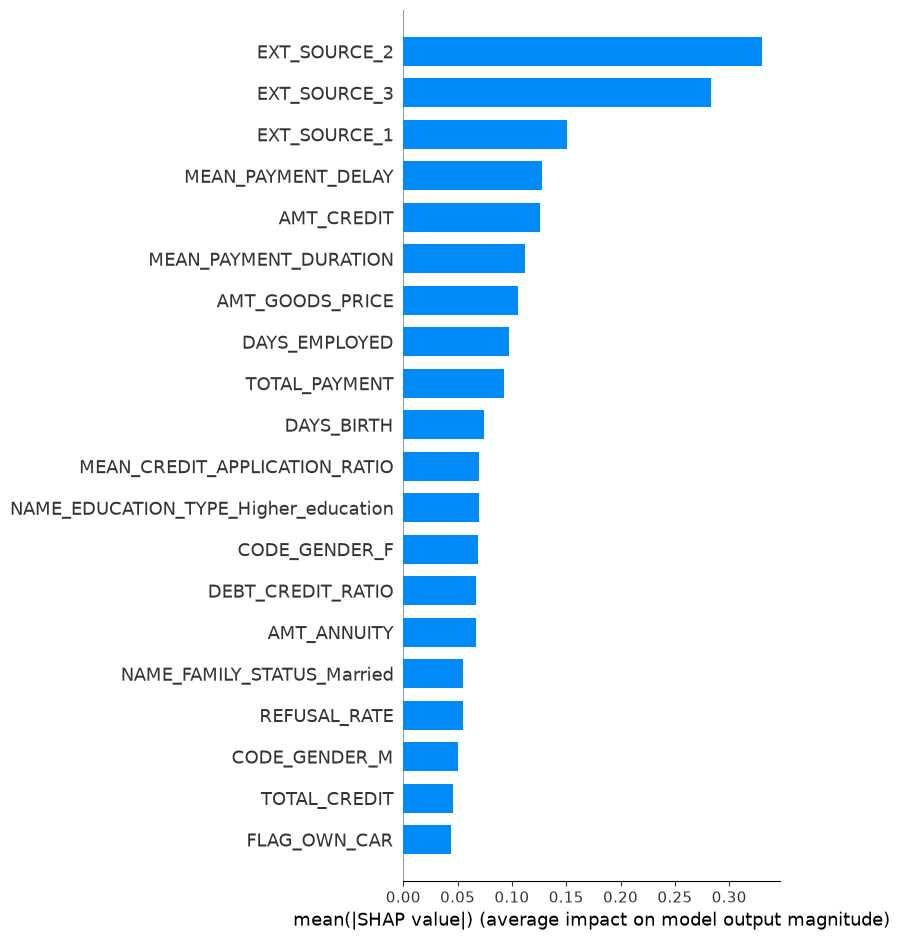

In [115]:
# ================================
# Explicabilité globale du meilleur modèle avec SHAP
# ================================

# Modèle sélectionné après GridSearch + optimisation du seuil

model = best_model

# ================================
# Création explainer SHAP LightGBM
# ================================

explainer = shap.TreeExplainer(model.booster_)

# ================================
# Échantillon validation
# ================================

X_validation_sample = X_validation.sample(n=1000,random_state=42)

# ================================
# Calcul des valeurs SHAP
# ================================

shap_values = explainer.shap_values(X_validation_sample)

# ================================
# Importance globale des variables
# ================================

plt.figure(figsize=(10,6))

shap.summary_plot(shap_values, X_validation_sample, plot_type="bar", max_display=20)

Ce graphique représente l'importance globale des variables utilisées par le modèle LightGBM. Les variables situées en haut du graphique sont celles qui contribuent le plus aux décisions du modèle. On observe que les variables les plus influentes sont principalement Ext_source_2, Ext_source_3 et Ext_source_1. Elles jouent donc un rôle majeur dans la prédiction du risque client.

### Feature importance locale

Client analysé : 8105
Probabilité de défaut : 31.67%
Décision finale : Risque faible


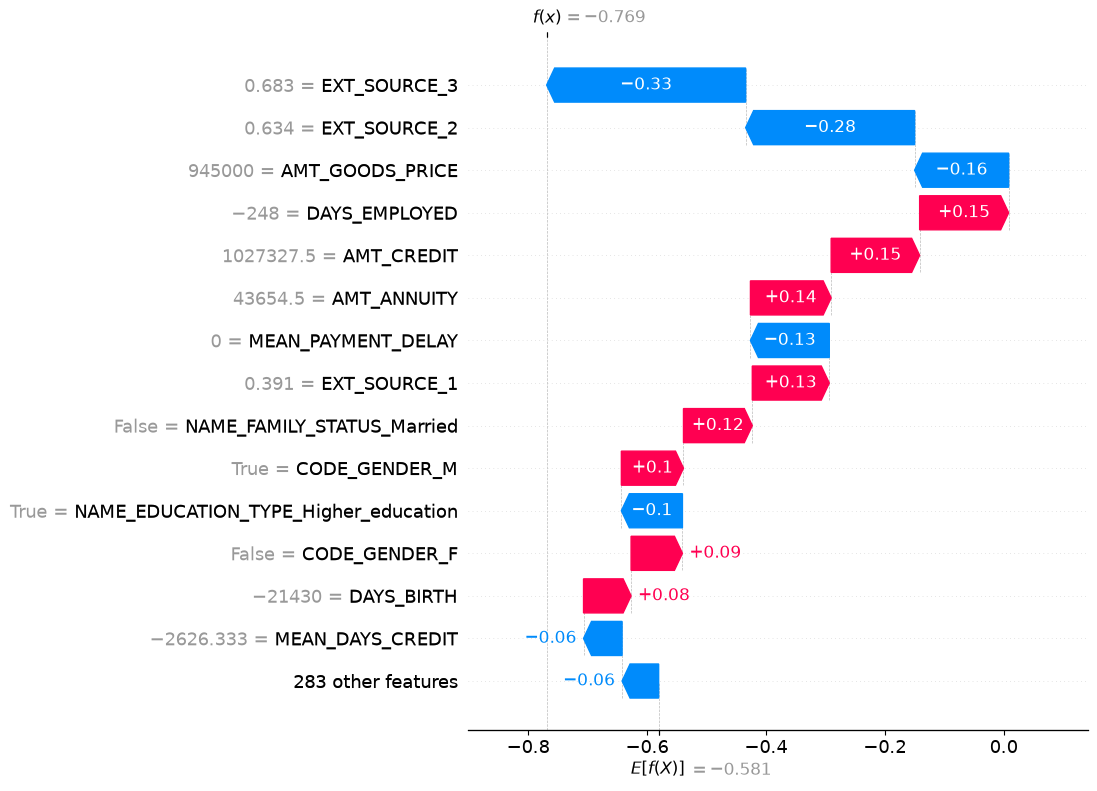

In [116]:
# ================================
# Explication locale d'un client
# ================================


# Sélection d'un client de validation

client_index = X_validation_sample.index[0]

client = X_validation.loc[[client_index]]


# Prédiction du modèle

client_probability = model.predict_proba(client)[0,1]


client_prediction = (client_probability >= best_threshold).astype(int)


print("Client analysé :", client_index)

print(f"Probabilité de défaut : {client_probability:.2%}")

print(f"Décision finale : {'Risque élevé' if client_prediction==1 else 'Risque faible'}")



# Calcul SHAP pour ce client

client_shap = explainer(client)



# Visualisation locale

shap.plots.waterfall(client_shap[0],max_display=15)

L'explication locale SHAP permet d'identifier les variables qui ont influencé la décision du modèle pour un client donné.

Pour ce client, les principaux facteurs diminuant le risque de défaut sont les scores externes de solvabilité (EXT_SOURCE_2 et EXT_SOURCE_3) ainsi que l'absence de retard de paiement (MEAN_PAYMENT_DELAY = 0).

À l'inverse, le montant du crédit (AMT_CREDIT), la mensualité (AMT_ANNUITY) et une faible ancienneté professionnelle (DAYS_EMPLOYED) contribuent à augmenter le risque estimé.

Cette analyse permet de rendre la décision du modèle plus interprétable en identifiant les facteurs ayant conduit à la prédiction finale.

## Conclusion

Ce projet a permis de développer un modèle de prédiction du risque de défaut en intégrant une approche orientée métier. Après comparaison des différents modèles et optimisation du seuil de décision, le modèle qui semble minimiser le cout métier, est LightGBM avec un seuil de 0.51.  
Avec les hyperparamètres: 
- learning_rate: 0.05  (taux d'apprentiassage, 0.05 (faible) signifie que chaque arbre corrige progressivement les précédents (donc apprentissage lent mais moins de surapprentissage).
- n_estimators: 200  (nombre d'arbres construits, plus il y a d'arbres plus le modèle est capables de capturer des relations complexes)
- num_leaves: 50 (profondeur maximale des arbres)

Ce modèle permet de détecter environ 66% des clients qui seront en défaut de paiement.